# GRADIENT BOOSTING (Histogram-based)

__INDEX__
1. [Understanding Gradient-Boosted Trees (Histogram-based)](#understanding)
2. [Setup and Data Preparation](#setup)
3. [Model Selection Experiments (Random Search and 8-Fold CV)](#expruns)

    3.1. [Full Feature Set Experiment](#allfeat)

    3.2. [Feature Ablation: Excluding previousOwners](#noprevown)

    3.3. [Feature Engineering Ablations and Additions](#feateng)

4. [Conclusions](#conclusions)


## 1. Understanding Gradient-Boosted Trees (Histogram-based) <a id="understanding"></a>

We focus on scikit-learn's Histogram-based Gradient Boosting Regression Tree, implemented as __HistGradientBoostingRegressor__. This estimator is designed for efficiency on larger datasets: according to the official documentation, it is much faster than GradientBoostingRegressor for big datasets (n_samples >= 10 000).

<div style="text-align: justify; max-width: 1300px; margin: 0 auto;">

- Scikit-learn provides us with two options to implement this algorithm (they are available both for classification and regression, but we will only focus on the regression ones):
    - __'HistGradientBoostingRegressor'__ and
    - __'GradientBoostingRegressor'__

- For small datasets, the use of bins might contribute to very close split points, hence why, in this case, __'GradientBoostingRegressor'__ is preferable. However, our dataset granularity is moderately high and, as indicated by the official documentation, for datasets with tens of thousands of samples, __'HistGradientBoostingRegressor'__ is preferable. 

- In addition, __'HistGradientBoostingRegressor'__ has the advantage of increased time efficiency compared to __'GradientBoostingRegressor'__. However, the former does not natively support some features of the latter. 


- The parameters explored for model optimisation (during the random search) in our project were the following: `max_iter`, `learning_rate`, `max_leaf_nodes`, `max_depth`, `l2_regularization`, `min_samples_leaf` and `loss`.

    
Note: all of these information are available at the scikit learn documentation.

</div>

## 2. Setup and Data Preparation  <a id="setup"></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
import os
from sklearn.feature_selection import SelectFromModel
import random
import logging
from IPython.display import display

In [ ]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def bias(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) - np.asarray(y_pred)))

def get_random_configs(n_iter: int):
    configs = []
    keys = list(param_distributions.keys())
    for i in range(n_iter):
        params = {k: random.choice(list(param_distributions[k])) for k in keys}

        name = (
            f"R{i}_iter{params['max_iter']}"
            f"_lr{float(params['learning_rate']):.3f}"
            f"_l2{float(params['l2_regularization']):.2f}"
            f"_leaf{params['max_leaf_nodes']}"
        )
        configs.append((name, params))
    return configs

def _normalize_cats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in cols_to_normalize:
        if col in df.columns:
            df[col] = fill_unknown(df[col])
            df = column_string_transformer(df, column=col, remove_middle_spaces=True, allow_extra_chars="")
    return df

In [ ]:
%run 02_visualization_helpers.ipynb  

In [ ]:
# All of our preprocessing helper functions are in this notebook
%run 00_preproc_helpers.ipynb  

# this is the target column - the value we want to predict 
TARGET_COL = "price"  

# separate features and target variable from the full training datase
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# at this point, this are all the features in use 
categorical_features = ['Brand', 'model', 'transmission', 'fuelType']              
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

N_SPLITS = 8 # the number of folds for K-Fold cross-validation
RANDOM_STATE = 42 # seed to control randomness
random.seed(RANDOM_STATE) # additional randomness control
np.random.seed(RANDOM_STATE) # additional randomness control - for numpy

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


## 3. Model Selection Experiments (Random Search and 8-Fold CV)  <a id="expruns"></a>

<div style="text-align: justify; max-width: 1300px; margin: 1 auto;">

- For this model, we ran multiple experiments because it was our best-performing approach (at the time) and we aimed to further optimize its performance. As a result, several settings were explored in more depth in this notebook. As mentioned earlier, when selecting a feature selection strategy, our primary goal, besides a correct implementation, was to identify a method that works well for this specific model. This is why the notebook includes a wider range of feature-selection percentages and why we ultimately converged on the selected values. A more detailed discussion of the feature selection procedure is provided in the corresponding section.

- Another consideration we wanted to highlight is that, since HistGradientBoosting (HGB) can naturally handle unscaled numeric variables, we initially chose not to apply feature scaling in this model. However, to validate that this decision was not harming performance - or creating an unfair comparison with other models where scaling might be essential - we repeated the previousOwners exclusion + log transformed target experiment in two versions: with and without scaling. We ran this check under this specific setting because it matches the one used in our final approach (the stacking setup) and it produced the same best hyperparameter configuration. Nevertheless, the top RMSE results were slightly worse when scaling was applied. Although this comparison was only performed for a single experimental setting (and therefore can not be generalized with full confidence), we decided to keep the notebook consistent and omit scaling for this HGB configuration. This choice also preserves fairness across models, since each model is reported under the preprocessing that produced its best performance (and scaling did not yield HGB's best performance in our tests). Finally, the observed differences were marginal, so this decision does not materially affect the conclusions.

</div>

### 3.1. Full Feature Set Experiment <a id="allfeat"></a>

- In this section, we performed a random search to check whether the chosen hyperparameters search space was reasonable and to establish baseline results for the next improvements.

In [ ]:
# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "max_iter": [600, 800, 1000], # max number of trees 
    "learning_rate": [0.05, 0.1, 0.15], # shrinkage factor (for the leaves values) 
    "max_leaf_nodes": [31, 63, 127], # max number of leaves for each tree
    "max_depth": [None, 10, 20, 11, 15], # max depth of each tree
    "l2_regularization": [0, 1, 2, 5], # regularization (penalization) factor for small hessian values leaves  
    "min_samples_leaf": [20, 40] # min number of samples for each leaf
}

N_RANDOM_CONFIGS = 10 

# we get N_RANDOM_CONFIGS (10) random parameter combinations from param_distributions 
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] # to store results of each configuration, to store the ranking

# tracking the best configuration according to validation RMSE 
best_rmse = np.inf 
best_config = None 

# to store our fold results
log_dir = "gb_logs" # directory to save log files that is not present in this final version but was useful during development
os.makedirs(log_dir, exist_ok=True)  # creates the log directory if it doesn't exist
log_filename = "2gb_complete_nof_log2.txt"
log_path = os.path.join(log_dir, log_filename)
# Note: this section is mainly for organization purposes and is not particularly relevant 


with open(log_path, "w", encoding="utf-8") as log_file:

    # this function allows printing the messages to the screen and to the log file 
    def log(msg: str):
        print(msg) 
        log_file.write(msg + "\n") 
        log_file.flush() 

    # header for the log file - just for readability and general info
    log("# =============================")
    log(f"# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    # loop that iterates over each random configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########") 
        log(f"Parameters: {params}")

        # we are storing the metrics for each fold here
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        # for each configuration, we do K-Fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # data split for the current fold
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")


            # -> Preprocessing Steps 
            # fit is only done with the training data 
            # we aplly the transformations (some obtained through fit) to both train and validation sets
            # all preprocessing functions are explained before, here we just apply them in order
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state) 

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)


            # -> Feature Encoding
            # applied to categorical features only
            # we separate high cardinality and low cardinality categorical features
            high_card_features = ["Brand", "model"] # target encoding for these
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train) # fit on training data
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features]) # fit on training data
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            # rejoining the categorical features (that are now encoded)
            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # joining numerical and categorical (encoded) features 
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            # here, we log the features name, to keep track of what is being used from the original set
            # but also because the columns increase due to encoding
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")
            
            # -> Model Training 
            # params contains the hyperparameters for this configuration
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train)

            # predictions on train and validation fold
            y_pred_train = hgb_model.predict(X_train_final)
            y_pred_val   = hgb_model.predict(X_val_final)

            # -> Metrics Calculation
            # Training metrics:
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)
            # Validation metrics:
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # logging the metrics of this fold
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")
            # storing the metrics of this fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # after all folds, we calculate the mean metrics across them
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        # logging and storing these results
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        # our best configuration is defined by the best rmse
        # by best, we mean the lowest rmse
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")


# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: gb_logs/2gb_complete_nof_log2.txt
# =============================

######## CONFIG 1/10 ########
Parameters: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 1000, 'max_depth': 20, 'learning_rate': 0.05, 'l2_regularization': 5}

[C1|F1] Processing fold...
  > Features Used (16): ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9612 | RMSE: 1925 | MAE: 1184 | Bias: 5.8
  > [VAL]   R2: 0.9560 | RMSE: 1994 | MAE: 1309 | Bias: -34.4

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9652 | RMSE: 1817 | MAE: 1181 | Bias: 1.3
  > [VAL]   R2: 0.9492 | RMSE: 2183 | MAE: 1338 | Bias: -17.5

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.9654 | RMSE: 1812 | MAE

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
7,8,0.10,600,2125.233451,1275.983400,0.952201,0.971785,4.737378
3,4,0.15,1000,2141.241796,1285.491288,0.951461,0.971734,4.125591
0,1,0.05,1000,2149.155596,1300.537692,0.951116,0.966733,3.805484
1,2,0.15,600,2173.992172,1332.511138,0.949999,0.963367,3.648160
8,9,0.15,1000,2178.584487,1329.102007,0.949742,0.962944,1.478192



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': 20, 'learning_rate': 0.1, 'l2_regularization': 0}


### 3.2. Feature Ablation Experiment: Excluding `previousOwners` and Applying a Log-Transformed Target (price) <a id="noprevown"></a>

- As previously stated, we conducted this experiment for two versions: without and with scaling.

#### 3.2.1. Feature Ablation Experiment: Excluding `previousOwners` and Applying a Log-Transformed Target (price) without Scaling

In [ ]:
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg'] # we removed previousOwners feature from here

# shuffles the data, in order to (at least theoretically) have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# we remove previousOwners from the features used by the model
# by doing this, we ensure it won't be in X_train/val
DROP_FROM_MODEL = ["previousOwners"]

# hyperparameter space that we are going to use for random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "loss": ["squared_error", "absolute_error"], # loss function used for boosting
    "learning_rate": [0.07, 0.085, 0.1, 0.115], # shrinkage factor (for the leaves values) 
    "max_iter": [600, 800, 1000, 1200], # max number of trees 
    "max_leaf_nodes": [63, 127, 191, 255], # max number of leaves for each tree
    "l2_regularization": [0.3, 1.0, 3.0], # regularization (penalization) factor for small hessian values leaves  
    "min_samples_leaf": [12, 16, 20, 28], # min number of samples for each leaf
    "max_depth": [15, 20, 25, None], # max depth of each tree
}

N_RANDOM_CONFIGS = 15  

# we get N_RANDOM_CONFIGS (15) random parameter combinations from param_distributions
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] # to store results of each configuration, to store the ranking

# tracking the best configuration according to validation RMSE
best_rmse = np.inf
best_config = None

# to store our fold results
log_dir = "gb_logs" # directory to save log files that is not present in this final version but was useful during development
os.makedirs(log_dir, exist_ok=True) # creates the log directory if it doesn't exist
log_filename = "2gb_noowners_nof_log.txt"
log_path = os.path.join(log_dir, log_filename)
# Note: this section was mainly for organization purposes and is not particularly relevant 

with open(log_path, "w", encoding="utf-8") as log_file:

    # this function allows printing the messages to the screen and to the log file 
    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    # header for the log file - just for readability and general info
    log("# =============================")
    log("# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    # loop that iterates over each random configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # we are storing the metrics for each fold here
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
        fold_med_ae = []

        # for each configuration, we do K-Fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            # data split for the current fold
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # -> Preprocessing Steps 
            # fit is only done with the training data 
            # we aplly the transformations (some obtained through fit) to both train and validation sets
            # all preprocessing functions are explained before, here we just apply them in order
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


            # ensures previousOwners is not used by the model 
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature Encoding
            # applied to categorical features only
            # we separate high cardinality and low cardinality categorical features
            high_card_features = ["Brand", "model"]  # target encoding for these
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)  # fit on training fold only
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])  # fit on training fold only
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            # rejoining the categorical features (that are now encoded)
            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # joining numerical and categorical (encoded) features 
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            # here, we log the features name, to keep track of what is being used from the original set
            # but also because the columns increase due to encoding
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            # -> Model training
            # params contains the hyperparameters for this configuration
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train)

            # predictions on train and validation fold
            y_pred_train = hgb_model.predict(X_train_final)
            y_pred_val   = hgb_model.predict(X_val_final)

            # -> Metrics calculation
            # Training metrics:
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)
            # Validation metrics:
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # logging the metrics of this fold
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            # storing the metrics of this fold
            fold_maes_tr.append(mae_tr);   fold_rmses_tr.append(rmse_tr);   fold_r2s_tr.append(r2_tr);   fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # after all folds, we calculate the mean metrics across them
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        # logging and storing these results
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,

            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        # our best configuration is defined by the best rmse
        # by best, we mean the lowest rmse
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)


# =============================
# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: gb_logs/2gb_noowners_nof_log.txt
# =============================

######## CONFIG 1/15 ########
Parameters: {'min_samples_leaf': 12, 'max_leaf_nodes': 255, 'max_iter': 800, 'max_depth': 20, 'loss': 'absolute_error', 'learning_rate': 0.085, 'l2_regularization': 0.3}

[C1|F1] Processing fold...
  > Features Used (15): ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9626 | RMSE: 1890 | MAE: 944 | Bias: 127.2
  > [VAL]   R2: 0.9577 | RMSE: 1956 | MAE: 1234 | Bias: 81.4

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9652 | RMSE: 1819 | MAE: 947 | Bias: 117.9
  > [VAL]   R2: 0.9543 | RMSE: 2072 | MAE: 1243 | Bias: 89.8

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.9664 | RMSE: 

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
2,3,0.100,1000,2099.530914,1255.499221,0.953341,0.973422,4.377196
8,9,0.100,800,2100.504347,1264.771234,0.953275,0.971701,4.474108
5,6,0.100,800,2102.091424,1266.021280,0.953168,0.972517,4.034098
6,7,0.115,1000,2103.075081,1266.134703,0.953180,0.971217,2.799125
4,5,0.115,1200,2104.173989,1255.819905,0.953120,0.976241,2.805482



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 191, 'max_iter': 1000, 'max_depth': 20, 'loss': 'squared_error', 'learning_rate': 0.1, 'l2_regularization': 3.0}


#### 3.2.2. Feature Ablation Experiment: Excluding `previousOwners` and Applying a Log-Transformed Target (price) with Scaling

In [ ]:
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg']  # we removed previousOwners feature from here

# shuffles the data, in order to (at least theoretically) have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# we remove previousOwners from the features used by the model
# by doing this, we ensure it won't be in X_train/_val
DROP_FROM_MODEL = ["previousOwners"]

# hyperparameter space that we are going to use for random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "loss": ["squared_error", "absolute_error"], # loss function used for boosting
    "learning_rate": [0.07, 0.085, 0.1, 0.115], # shrinkage factor (for the leaves values)
    "max_iter": [600, 800, 1000, 1200], # max number of trees
    "max_leaf_nodes": [63, 127, 191, 255],  # max number of leaves for each tree
    "l2_regularization": [0.3, 1.0, 3.0], # regularization factor
    "min_samples_leaf": [12, 16, 20, 28], # min number of samples for each leaf
    "max_depth": [15, 20, 25, None], # max depth of each tree
}

N_RANDOM_CONFIGS = 15  

# we get N_RANDOM_CONFIGS (15) random parameter combinations from param_distributions
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []  # to store results of each configuration, to store the ranking

# tracking the best configuration according to validation RMSE
best_rmse = np.inf
best_config = None

# to store our fold results
log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)
log_filename = "2gb_noowners_logprice.txt"  
log_path = os.path.join(log_dir, log_filename)

with open(log_path, "w", encoding="utf-8") as log_file:

    # this function allows printing the messages to the screen and to the log file
    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    # header for the log file - just for readability and general info
    log("# =============================")
    log("# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# Target transform: train on log1p(price); evaluate in euros via expm1(pred).")
    log("# =============================")

    # loop that iterates over each random configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # we are storing the metrics for each fold here
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
        fold_med_ae = []

        # for each configuration, we do K-Fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            # data split for the current fold
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            # log-target (TRAIN ONLY)
            y_train_log = np.log1p(y_train)

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # -> Preprocessing Steps
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # ensures previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature Encoding
            high_card_features = ["Brand", "model"]  # target encoding for these
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log) 
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])  
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            # rejoining the categorical features (encoded)
            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # NUMERICAL SCALING 
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])  # fit on train fold
            X_val_num   = scaler.transform(X_val[numeric_features])        # transform validation fold

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            # joining scaled numerical and categorical (encoded) features
            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # enforcing identical columns and identical order in validation
            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            # log feature names once (fold 1) for traceability
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            # -> Model training (LOG TARGET)
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train_log)

            # predictions in log-space
            y_pred_train_log = hgb_model.predict(X_train_final)
            y_pred_val_log   = hgb_model.predict(X_val_final)

            # back-transform to price for evaluation
            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics calculation (in price)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val    = mean_absolute_error(y_val, y_pred_val)
            rmse_val   = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val     = r2_score(y_val, y_pred_val)
            bias_val   = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr);   fold_rmses_tr.append(rmse_tr);   fold_r2s_tr.append(r2_tr);   fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # after all folds, we calculate the mean metrics across them
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr  = np.mean(fold_rmses_tr)
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] RMSE: {mean_rmse_tr:.1f} | MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   RMSE: {mean_rmse_val:.1f} | MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            "train_rmse": mean_rmse_tr,
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)
print(f"\nLogs stored at: {log_path}")


# =============================
# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: gb_logs/2gb_noowners_logprice.txt
# Target transform: train on log1p(price); evaluate in euros via expm1(pred).
# =============================

######## CONFIG 1/15 ########
Parameters: {'min_samples_leaf': 12, 'max_leaf_nodes': 255, 'max_iter': 800, 'max_depth': 20, 'loss': 'absolute_error', 'learning_rate': 0.085, 'l2_regularization': 0.3}

[C1|F1] Processing fold...
  > Features Used (15): ['num_year', 'num_mileage', 'num_engineSize', 'num_tax', 'num_mpg', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9623 | RMSE: 1896 | MAE: 949 | Bias: 132.6
  > [VAL]   R2: 0.9557 | RMSE: 2003 | MAE: 1248 | Bias: 101.6

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9636 | RMSE: 1858 | MAE: 949 | Bias: 133.5
  > [VAL]   R2: 0.95

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
2,3,0.100,1000,2111.819866,1235.816682,0.952794,0.972769,97.553676
5,6,0.100,800,2124.045425,1245.632409,0.952192,0.971306,101.590861
4,5,0.115,1200,2133.368223,1241.258880,0.951752,0.973807,98.258752
6,7,0.115,1000,2138.071797,1246.845811,0.951577,0.969968,98.646764
3,4,0.100,600,2139.151103,1249.314335,0.951567,0.968652,100.196872



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 191, 'max_iter': 1000, 'max_depth': 20, 'loss': 'squared_error', 'learning_rate': 0.1, 'l2_regularization': 3.0}

Logs stored at: gb_logs/2gb_noowners_logprice.txt


### 3.3. Feature Engineering: Ablations and Additions <a id="feateng"></a>

- In this section, we will analyse the behaviour of the model with different sets of features. 
- We will start by evaluating the model's overall performance with the complete set of original features (without paintQuality and hasDamage columns) together with the engineered ones, first without feature selection and then with feature selection. We will analyse different feature selection percentages, more specifically the ones that had the best two validation RMSE scores and the worst performing setting.
- Finally, we will exclude the previousOwners feature from the original features set and combine the set with just the engineered age feature.
- Throughout this section, we use a log-target strategy for the price (i.e., training on log(1 + price) and inverting predictions back to currency for evaluation).

#### 3.3.1. Original and Engineered Features (No Feature Selection) with Log-Transformed Target (price) <a id="featengnosel"></a>

- We ran a small random search without feature selection. We did not expect strong results, because keeping all of the engineered features would likely increase redundancy, but served as a baseline for comparison.

In [ ]:
N_ITER = 10 # number of iterations testing configurations in random search
# this is a short random search, enough for baseline results
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

# logging configurations
LOG_FILE = "random_search_fe_results_rmse_no_fs_iter10.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w", # overwrite log on each run
    force=True # ensures this config overrides any previous logging setup
)
logging.info(f"- {N_ITER} iterations | {N_SPLITS}-fold | NO_FEATURE_SELECTION")

# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "min_samples_leaf": [20, 30, 40], # min number of samples for each leaf
    "max_leaf_nodes": [31, 63, 127], # max number of leaves for each tree
    "max_iter": [600, 800, 1000, 1500], # max number of trees 
    "max_depth": [None, 10, 15, 20, 25], # max depth of each tree
    "learning_rate": np.linspace(0.08, 0.15, 20), # shrinkage factor (for the leaves values) 
    "l2_regularization": np.linspace(0.5, 2.5, 20), # regularization (penalization) factor for small hessian values leaves  
    "max_bins": [255], # this is already the default, but was added for completeness
    "random_state": [RANDOM_STATE],
}
# Note: linspace(a,b,n) will generate an array of n equally spaced values between a and b (inclusive)

# Sample N_ITER configs from the distributions 
CONFIGS = get_random_configs(N_ITER)

# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

# separate high and low cardinality categorical features for future encoding steps
high_card_features = ["Brand", "model"] # these for target encoding
low_card_features  = [c for c in categorical_features if c not in high_card_features] # these for one-hot encoding

# evaluates the configuration 
def eval_one_config(name: str, params: dict) -> dict:
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        # kf.split(X) returns the row indices for the train/validation split of each CV fold
        # fold starts at 1 just for cleaner logging (Fold 1, Fold 2, ...) 

        # Extract fold data by integer position
        # .copy() prevents in-fold transformations from accidentally affecting the original 
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        # train in log space to stabilize variance and therefore reduce skew 
        # y_log = log(1 + y). then we invert with expm1() to evaluate in currency
        y_train_log = np.log1p(y_train)

        # this was already performed, but just for safety
        X_train = _normalize_cats(X_train) 
        X_val   = _normalize_cats(X_val) 

        # keep only expected base columns 
        base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # guards 
        required = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners", "Brand", "model"]
        missing = [c for c in required if c not in X_train.columns]
        if missing:
            raise KeyError(f"[Fold {fold}] missing necessary columns in pipeline: {missing}")

        # -> Preprocessing Steps 
        # fit is only done with the training data 
        # we aplly the transformations (some obtained through fit) to both train and validation sets
        # all preprocessing functions are explained before, here we just apply them in order
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


        # -> Feature Engineering
        # replace previousOwners feature with the derived feature (and drop original)
        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

        # age feature: uses a fixed reference year (base_year=2020)
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        # mileage-derived features; drops original mileage and drops ratio feature
        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)

        # discretize engineSize into bins; treat as categorical (string) for OHE
        X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
        X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        low_card_curr = low_card_features + ["engine_bin"]

        # -> Encoding 
        # target encoder fits on train fold using y_train_log (preventing data leakage)
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        # One-hot encode low-cardinality categoricals; fits on train fold only
        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        # numerics are the ones left after encoding (because those encoded were the categorical) 
        drop_for_numeric = set(high_card_features + low_card_curr)
        numeric_features_curr = [c for c in X_train.columns if c not in drop_for_numeric]

        X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

        # ensure validation has exactly the same columns/order as train 
        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        # --> train on log target and for prediction invert back to currency
        n_feats = int(X_train_final.shape[1])

        model = HistGradientBoostingRegressor(**params)
        model.fit(X_train_final, y_train_log)

        pred_tr_log  = model.predict(X_train_final)
        pred_val_log = model.predict(X_val_final)

        pred_tr  = np.expm1(pred_tr_log)   
        pred_val = np.expm1(pred_val_log)  

       
        # --> metrics 
        fold_rows.append({
            "config": name,
            "fold": fold,
            "n_features": n_feats,

            "train_rmse": rmse(y_train, pred_tr),
            "val_rmse":   rmse(y_val,   pred_val),

            "train_mae": float(mean_absolute_error(y_train, pred_tr)),
            "val_mae":   float(mean_absolute_error(y_val,   pred_val)),

            "train_r2": float(r2_score(y_train, pred_tr)),
            "val_r2":   float(r2_score(y_val,   pred_val)),

            "train_bias": bias(y_train, pred_tr),
            "val_bias":   bias(y_val,   pred_val),
        })

    df_folds = pd.DataFrame(fold_rows)

    # mean after folds
    out = {
        "config": name,

        "val_rmse_mean": float(df_folds["val_rmse"].mean()),
        "train_rmse_mean": float(df_folds["train_rmse"].mean()),
        "val_mae_mean": float(df_folds["val_mae"].mean()),
        "train_mae_mean": float(df_folds["train_mae"].mean()),
        "val_r2_mean": float(df_folds["val_r2"].mean()),
        "train_r2_mean": float(df_folds["train_r2"].mean()),
        "val_bias_mean": float(df_folds["val_bias"].mean()),
        "train_bias_mean": float(df_folds["train_bias"].mean()),

        "avg_features": float(df_folds["n_features"].mean()),
        **params,
    }

    print(
        f"   >> [{name}] "
        f"VAL RMSE: {out['val_rmse_mean']:.1f} | VAL R2: {out['val_r2_mean']:.4f} | "
        f"VAL MAE: {out['val_mae_mean']:.1f} | VAL Bias: {out['val_bias_mean']:.1f} | "
        f"Feats: {out['avg_features']:.0f}"
    )

    logging.info(
        f"{name} | "
        f"VAL_RMSE={out['val_rmse_mean']:.6f} | VAL_MAE={out['val_mae_mean']:.6f} | "
        f"VAL_R2={out['val_r2_mean']:.6f} | VAL_BIAS={out['val_bias_mean']:.6f} | "
        f"TRAIN_RMSE={out['train_rmse_mean']:.6f} | TRAIN_MAE={out['train_mae_mean']:.6f} | "
        f"Params={params}"
    )

    return out

# results to store 
results = [] # stores the summary dict returned by each evaluated configuration
best_rmse = np.inf # to store the lowest therefore best validation rmse 
best_row = None # stores the full result dict of the current best config

# iterate over the sampled configurations (name, params)
for i, (name, params) in enumerate(CONFIGS):
    # just to oganize in blocks of 5 for easier result tracking while running 
    if i % 5 == 0:
        print(f"\n-- doing {i+1}/{len(CONFIGS)}")

    # evaluate one configuration (returns fold metrics and params)
    res = eval_one_config(name, params)
    results.append(res)

    # we are looking for the best rmse, the lowest 
    if res["val_rmse_mean"] < best_rmse:
        best_rmse = res["val_rmse_mean"]
        best_row = res

results_df = pd.DataFrame(results) # converting to a dataframe for a better exploration of results 

# final results 
print("\n- TOP 10 Configurations (sorted by VAL RMSE)")
# sort configurations by validation RMSE (ascending = best first)
results_df_sorted = results_df.sort_values("val_rmse_mean", ascending=True)

# columns to display in the summary table
cols_show = [
    "config",
    "val_rmse_mean", "val_mae_mean", "val_r2_mean", "val_bias_mean",
    "train_rmse_mean", "train_mae_mean", "train_r2_mean", "train_bias_mean",
    "avg_features",
    "learning_rate", "max_iter", "l2_regularization", "max_leaf_nodes", "max_depth", "min_samples_leaf"
]

display(results_df_sorted[cols_show].head(10))

OUT_CSV = "random_search_fe_results_rmse_no_fs_iter10.csv"
results_df_sorted.to_csv(OUT_CSV, index=False)
print(f"stored at: {OUT_CSV}")
print(f"log in: {LOG_FILE}")

print("\n- BEST CONFIG (by VAL RMSE)")
print(f"Best config name: {best_row['config']}")
print(f"VAL RMSE: {best_row['val_rmse_mean']:.3f}")
print(f"VAL R2:   {best_row['val_r2_mean']:.6f}")
print(f"VAL MAE:  {best_row['val_mae_mean']:.3f}")
print(f"VAL Bias: {best_row['val_bias_mean']:.3f}")
print("Params:")
best_params = {k: best_row[k] for k in param_distributions.keys() if k in best_row}
print(best_params)



-- doing 1/10
   >> [R0_iter600_lr0.106_l21.24_leaf31] VAL RMSE: 2225.2 | VAL R2: 0.9476 | VAL MAE: 1307.9 | VAL Bias: 111.5 | Feats: 25
   >> [R1_iter600_lr0.128_l20.61_leaf127] VAL RMSE: 2175.0 | VAL R2: 0.9499 | VAL MAE: 1271.0 | VAL Bias: 101.4 | Feats: 25
   >> [R2_iter600_lr0.102_l22.29_leaf31] VAL RMSE: 2193.7 | VAL R2: 0.9491 | VAL MAE: 1301.1 | VAL Bias: 115.0 | Feats: 25
   >> [R3_iter1000_lr0.098_l21.87_leaf127] VAL RMSE: 2173.4 | VAL R2: 0.9500 | VAL MAE: 1265.0 | VAL Bias: 102.9 | Feats: 25
   >> [R4_iter1000_lr0.087_l21.76_leaf31] VAL RMSE: 2189.9 | VAL R2: 0.9492 | VAL MAE: 1294.7 | VAL Bias: 112.4 | Feats: 25

-- doing 6/10
   >> [R5_iter1000_lr0.132_l22.29_leaf127] VAL RMSE: 2167.0 | VAL R2: 0.9503 | VAL MAE: 1264.1 | VAL Bias: 101.6 | Feats: 25
   >> [R6_iter1000_lr0.121_l22.39_leaf127] VAL RMSE: 2170.0 | VAL R2: 0.9501 | VAL MAE: 1266.2 | VAL Bias: 104.0 | Feats: 25
   >> [R7_iter800_lr0.087_l21.24_leaf127] VAL RMSE: 2166.4 | VAL R2: 0.9503 | VAL MAE: 1263.0 | VAL B

,config,val_rmse_mean,val_mae_mean,val_r2_mean,val_bias_mean,train_rmse_mean,train_mae_mean,train_r2_mean,train_bias_mean,avg_features,learning_rate,max_iter,l2_regularization,max_leaf_nodes,max_depth,min_samples_leaf
7,R7_iter800_lr0.087_l21.24_leaf127,2166.385636,1262.987293,0.950291,104.271149,1697.414446,1028.139550,0.969588,85.164179,25.0,0.087368,800,1.236842,127,15.0,20
5,R5_iter1000_lr0.132_l22.29_leaf127,2166.981137,1264.079945,0.950273,101.644585,1717.620724,1033.924597,0.968850,84.632881,25.0,0.131579,1000,2.289474,127,NaN,30
6,R6_iter1000_lr0.121_l22.39_leaf127,2169.994360,1266.230068,0.950115,104.016112,1700.687504,1028.594273,0.969443,85.630438,25.0,0.120526,1000,2.394737,127,25.0,20
9,R9_iter600_lr0.098_l22.29_leaf127,2170.726456,1268.151996,0.950127,102.562385,1751.553143,1051.351428,0.967598,86.618482,25.0,0.098421,600,2.289474,127,25.0,40
3,R3_iter1000_lr0.098_l21.87_leaf127,2173.421628,1264.973215,0.949975,102.927068,1727.576938,1036.941120,0.968480,85.725725,25.0,0.098421,1000,1.868421,127,NaN,30
1,R1_iter600_lr0.128_l20.61_leaf127,2175.046506,1270.965401,0.949919,101.432846,1756.899416,1055.321461,0.967371,86.493603,25.0,0.127895,600,0.605263,127,25.0,40
8,R8_iter1000_lr0.121_l21.66_leaf63,2177.618806,1280.533570,0.949837,105.213004,1817.881511,1104.956383,0.965112,90.584649,25.0,0.120526,1000,1.657895,63,10.0,30
4,R4_iter1000_lr0.087_l21.76_leaf31,2189.868643,1294.659359,0.949240,112.414340,1896.325233,1161.230452,0.962056,99.985493,25.0,0.087368,1000,1.763158,31,NaN,20
2,R2_iter600_lr0.102_l22.29_leaf31,2193.745759,1301.096574,0.949088,114.985999,1919.419481,1174.947244,0.961134,101.419823,25.0,0.102105,600,2.289474,31,25.0,20
0,R0_iter600_lr0.106_l21.24_leaf31,2225.164094,1307.947911,0.947640,111.548682,1965.545765,1190.466069,0.959240,102.107846,25.0,0.105789,600,1.236842,31,15.0,40


stored at: random_search_fe_results_rmse_no_fs_iter10.csv
log in: random_search_fe_results_rmse_no_fs_iter10.log

- BEST CONFIG (by VAL RMSE)
Best config name: R7_iter800_lr0.087_l21.24_leaf127
VAL RMSE: 2166.386
VAL R2:   0.950291
VAL MAE:  1262.987
VAL Bias: 104.271
Params:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 800, 'max_depth': 15, 'learning_rate': np.float64(0.08736842105263158), 'l2_regularization': np.float64(1.236842105263158), 'max_bins': 255, 'random_state': 42}


#### 3.3.2. Original and Engineered Features with Feature Selection and Log-Transformed Target (price) <a id="featengsel"></a>

- In these experiments, we ran multiple random searches with different feature selection percentages to evaluate which one performs the best.
- We tested the following percentages of feature selection: 40%, 55%, 60%, 65%, 70%, 75% and 80%. We only kept, in this notebook, the percentages 40% (the worst result obtained), 70% (the second best) and 65% (the best result).

##### 3.3.2.1. Original and Engineered Features: Top 65% Features by Importance

In [ ]:
N_ITER = 35 #number of iterations testing configurations in random search
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

FS_KEEP_RATIO = 0.65  # feature ratio to keep after feature selection (65%)

# there are parameters for the Random Forest used in feature selection
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# log configurations
LOG_FILE = "random_search_fe_fs_results_rmse_fs65m_iter35.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w", # overwrite log on each run
    force=True # ensures this configuration overrides any previous logging setup
)
logging.info(f"- {N_ITER} iterations | {N_SPLITS}-fold | FS_KEEP_RATIO={FS_KEEP_RATIO}")

# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "min_samples_leaf": [20, 30, 40], # min number of samples for each leaf
    "max_leaf_nodes": [31, 63, 127], # max number of leaves for each tree
    "max_iter": [600, 800, 1000, 1500], # max number of trees 
    "max_depth": [None, 10, 15, 20, 25], # max depth of each tree
    "learning_rate": np.linspace(0.08, 0.15, 20), # shrinkage factor (for the leaves values) 
    "l2_regularization": np.linspace(0.5, 2.5, 20), # regularization (penalization) factor for small hessian values leaves  
    "max_bins": [255], # this is already the default, but was added for completeness
    "random_state": [RANDOM_STATE],
}
# Note: linspace(a,b,n) will generate an array of n equally spaced values between a and b (inclusive)

CONFIGS = get_random_configs(N_ITER) # Sample N_ITER configs from the distributions 


# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

# separate high and low cardinality categorical features for future encoding steps
high_card_features = ["Brand", "model"] # these for target encoding
low_card_features  = [c for c in categorical_features if c not in high_card_features] # these for one-hot encoding


# evaluates the configuration 
def eval_one_config(name: str, params: dict) -> dict:
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        # kf.split(X) returns the row indices for the train/validation split of each CV fold
        # fold starts at 1 just for cleaner logging (Fold 1, Fold 2, ...) 

        # Extract fold data by integer position
        # .copy() prevents in-fold transformations from accidentally affecting the original 
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        # train in log space to stabilize variance and therefore reduce target skew 
        # y_log = log(1 + y). then we invert with expm1() to evaluate in currency
        y_train_log = np.log1p(y_train)

        # this was already performed, but just for safety
        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        # keep only expected base columns 
        base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # guards
        required = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners", "Brand", "model"]
        missing = [c for c in required if c not in X_train.columns]
        if missing:
            raise KeyError(f"[Fold {fold}] missing columns needed in pipeline: {missing}")

        # -> Preprocessing Steps 
        # fit is only done with the training data 
        # we aplly the transformations (some obtained through fit) to both train and validation sets
        # all preprocessing functions are explained before, here we just apply them in order
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


        # -> Feature Engineering
        # replace previousOwners feature with derived feature (and drop original)
        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

        # age feature: uses a fixed reference year (base_year=2020)
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        # mileage-derived features; drops original mileage
        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
    
        # discretize engineSize into bins; treat as categorical (string) for OHE
        X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
        X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        low_card_curr = low_card_features + ["engine_bin"]

        # -> Encoding 
        # target encoder fits on train fold using y_train_log 
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        # One-hot encode low-cardinality categoricals; fits on train fold only
        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        # numerics are the ones left after encoding (because those encoded were the categorical) 
        drop_for_numeric = set(high_card_features + low_card_curr)
        numeric_features_curr = [c for c in X_train.columns if c not in drop_for_numeric]

        X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

        # ensure validation has exactly the same columns/order as train 
        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)


        # --> Feature Selection
        n_feats = X_train_final.shape[1] # total number of engineered + encoded features available in this fold
        
        # ceil ensures we don't keep fewer features due to rounding
        # clamp to [1, n_feats] guarantees a valid number of selected features
        k = int(np.ceil(FS_KEEP_RATIO * n_feats))
        k = max(1, min(k, n_feats))

        # train a random forest on the train fold only to estimate feature importances
        # We use y_train_log because the main model is trained in log-target space as well
        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        # SelectFromModel will keep the k most important features
        # threshold = -inf means not filtering by importance threshold
        # selection is controlled primarily by max_features = k
        #  prefit=True indicates rf_fs is already fitted, so SelectFromModel won't refit it.
        selector = SelectFromModel(
            estimator=rf_fs,
            threshold=-np.inf,
            max_features=k,
            prefit=True
        )

        # Boolean mask of selected features based on rf_fs.feature_importances_
        selected_cols = X_train_final.columns[selector.get_support()]

        # Apply the same selected feature subset to both train and validation folds
        X_train_sel = X_train_final[selected_cols]
        X_val_sel   = X_val_final[selected_cols]

        # --> train on log target and for prediction invert back to currency
        model = HistGradientBoostingRegressor(**params)
        model.fit(X_train_sel, y_train_log)

        pred_tr_log  = model.predict(X_train_sel)
        pred_val_log = model.predict(X_val_sel)

        pred_tr  = np.expm1(pred_tr_log)   
        pred_val = np.expm1(pred_val_log)  

        # --> metrics 
        rmse_tr = rmse(y_train, pred_tr)
        rmse_val = rmse(y_val, pred_val)

        mae_tr = float(mean_absolute_error(y_train, pred_tr))
        mae_val = float(mean_absolute_error(y_val, pred_val))

        r2_tr = float(r2_score(y_train, pred_tr))
        r2_val = float(r2_score(y_val, pred_val))

        bias_tr = bias(y_train, pred_tr)
        bias_val = bias(y_val, pred_val)

        fold_rows.append({
            "config": name,
            "fold": fold,
            "n_features_total": int(n_feats),
            "n_features_selected": int(len(selected_cols)),

            "train_rmse": rmse_tr,
            "val_rmse": rmse_val,
            "train_mae": mae_tr,
            "val_mae": mae_val,
            "train_r2": r2_tr,
            "val_r2": r2_val,
            "train_bias": bias_tr,
            "val_bias": bias_val,
        })

    df_folds = pd.DataFrame(fold_rows)

    # mean after folds
    out = {
        "config": name,

        "val_rmse_mean": float(df_folds["val_rmse"].mean()),
        "train_rmse_mean": float(df_folds["train_rmse"].mean()),
        "val_mae_mean": float(df_folds["val_mae"].mean()),
        "train_mae_mean": float(df_folds["train_mae"].mean()),
        "val_r2_mean": float(df_folds["val_r2"].mean()),
        "train_r2_mean": float(df_folds["train_r2"].mean()),
        "val_bias_mean": float(df_folds["val_bias"].mean()),
        "train_bias_mean": float(df_folds["train_bias"].mean()),

        "avg_selected_features": float(df_folds["n_features_selected"].mean()),
        "avg_total_features": float(df_folds["n_features_total"].mean()),
        **params,
    }

    print(
        f"   >> [{name}] "
        f"VAL RMSE: {out['val_rmse_mean']:.1f} | VAL R2: {out['val_r2_mean']:.4f} | "
        f"VAL MAE: {out['val_mae_mean']:.1f} | VAL Bias: {out['val_bias_mean']:.1f} | "
        f"Sel: {out['avg_selected_features']:.0f} feats"
    )

    logging.info(
        f"{name} | "
        f"VAL_RMSE={out['val_rmse_mean']:.6f} | VAL_MAE={out['val_mae_mean']:.6f} | "
        f"VAL_R2={out['val_r2_mean']:.6f} | VAL_BIAS={out['val_bias_mean']:.6f} | "
        f"TRAIN_RMSE={out['train_rmse_mean']:.6f} | TRAIN_MAE={out['train_mae_mean']:.6f} | "
        f"SelAvg={out['avg_selected_features']:.3f} | Params={params}"
    )

    return out

# results to store 
results = [] # stores the summary dict returned by each evaluated configuration
best_rmse = np.inf # to store the lowest therefore best validation rmse 
best_row = None  # stores the full result dict of the current best config

# iterate over the sampled configurations (name, params)
for i, (name, params) in enumerate(CONFIGS):
    # just to oganize in blocks of 5 for easier result tracking while running 
    if i % 5 == 0:
        print(f"\n-- doing {i+1}/{len(CONFIGS)}")

    # evaluate one configuration (returns fold metrics and params)
    res = eval_one_config(name, params)
    results.append(res)

    # we are looking for the best rmse, the lowest 
    if res["val_rmse_mean"] < best_rmse:
        best_rmse = res["val_rmse_mean"]
        best_row = res

results_df = pd.DataFrame(results) # converting to a dataframe for a better exploration of results 

# final results 
print("\n- TOP 10 Configurations (sorted by VAL RMSE)")
# sort configurations by validation RMSE (ascending = best first)
results_df_sorted = results_df.sort_values("val_rmse_mean", ascending=True)

# columns to display in the summary table
cols_show = [
    "config",
    "val_rmse_mean", "val_mae_mean", "val_r2_mean", "val_bias_mean",
    "train_rmse_mean", "train_mae_mean", "train_r2_mean", "train_bias_mean",
    "avg_selected_features",
    "learning_rate", "max_iter", "l2_regularization", "max_leaf_nodes", "max_depth", "min_samples_leaf"
]

display(results_df_sorted[cols_show].head(10))

OUT_CSV = "random_search_fe_fs_results_rmse_fs65m_iter35.csv"
results_df_sorted.to_csv(OUT_CSV, index=False)
print(f"stored at: {OUT_CSV}")
print(f"log in: {LOG_FILE}")

print("\n- BEST CONFIG (by VAL RMSE)")
print(f"Best config name: {best_row['config']}")
print(f"VAL RMSE: {best_row['val_rmse_mean']:.3f}")
print(f"VAL R2:   {best_row['val_r2_mean']:.6f}")
print(f"VAL MAE:  {best_row['val_mae_mean']:.3f}")
print(f"VAL Bias: {best_row['val_bias_mean']:.3f}")
print("Params:")
best_params = {k: best_row[k] for k in param_distributions.keys() if k in best_row}
print(best_params)



-- doing 1/35
   >> [R0_iter600_lr0.106_l21.24_leaf31] VAL RMSE: 2216.7 | VAL R2: 0.9480 | VAL MAE: 1308.7 | VAL Bias: 111.4 | Sel: 17 feats
   >> [R1_iter600_lr0.128_l20.61_leaf127] VAL RMSE: 2164.8 | VAL R2: 0.9504 | VAL MAE: 1268.1 | VAL Bias: 101.9 | Sel: 17 feats
   >> [R2_iter600_lr0.102_l22.29_leaf31] VAL RMSE: 2198.1 | VAL R2: 0.9489 | VAL MAE: 1306.0 | VAL Bias: 112.5 | Sel: 17 feats
   >> [R3_iter1000_lr0.098_l21.87_leaf127] VAL RMSE: 2171.3 | VAL R2: 0.9501 | VAL MAE: 1264.7 | VAL Bias: 103.9 | Sel: 17 feats
   >> [R4_iter1000_lr0.087_l21.76_leaf31] VAL RMSE: 2183.8 | VAL R2: 0.9496 | VAL MAE: 1294.7 | VAL Bias: 111.9 | Sel: 17 feats

-- doing 6/35
   >> [R5_iter1000_lr0.132_l22.29_leaf127] VAL RMSE: 2164.9 | VAL R2: 0.9504 | VAL MAE: 1265.3 | VAL Bias: 103.3 | Sel: 17 feats
   >> [R6_iter1000_lr0.121_l22.39_leaf127] VAL RMSE: 2138.9 | VAL R2: 0.9516 | VAL MAE: 1255.0 | VAL Bias: 103.2 | Sel: 17 feats
   >> [R7_iter800_lr0.087_l21.24_leaf127] VAL RMSE: 2146.3 | VAL R2: 0.95

,config,val_rmse_mean,val_mae_mean,val_r2_mean,val_bias_mean,train_rmse_mean,train_mae_mean,train_r2_mean,train_bias_mean,avg_selected_features,learning_rate,max_iter,l2_regularization,max_leaf_nodes,max_depth,min_samples_leaf
6,R6_iter1000_lr0.121_l22.39_leaf127,2138.946463,1254.963079,0.951583,103.213963,1656.389980,1000.731919,0.971014,82.265408,17.0,0.120526,1000,2.394737,127,25.0,20
7,R7_iter800_lr0.087_l21.24_leaf127,2146.293246,1255.629198,0.951206,102.687599,1682.127425,1019.793927,0.970105,83.743940,17.0,0.087368,800,1.236842,127,15.0,20
8,R8_iter1000_lr0.121_l21.66_leaf63,2157.920751,1277.729013,0.950724,101.917490,1806.662760,1101.812486,0.965512,89.622359,17.0,0.120526,1000,1.657895,63,10.0,30
9,R9_iter600_lr0.098_l22.29_leaf127,2160.865464,1263.816194,0.950583,104.621739,1753.936585,1053.095915,0.967526,86.500598,17.0,0.098421,600,2.289474,127,25.0,40
34,R34_iter1500_lr0.139_l21.03_leaf127,2162.574254,1258.106493,0.950473,99.677590,1662.200825,1006.441463,0.970830,81.860099,17.0,0.138947,1500,1.026316,127,25.0,20
11,R11_iter1500_lr0.087_l21.13_leaf63,2163.110780,1275.262067,0.950530,106.011979,1803.525756,1102.379204,0.965650,93.020385,17.0,0.087368,1500,1.131579,63,15.0,20
1,R1_iter600_lr0.128_l20.61_leaf127,2164.811904,1268.102162,0.950376,101.889555,1761.153552,1056.443370,0.967263,86.124336,17.0,0.127895,600,0.605263,127,25.0,40
5,R5_iter1000_lr0.132_l22.29_leaf127,2164.863203,1265.272584,0.950386,103.267536,1728.950756,1042.026496,0.968432,85.004594,17.0,0.131579,1000,2.289474,127,NaN,30
13,R13_iter1000_lr0.128_l22.39_leaf127,2165.156544,1266.720002,0.950371,101.999496,1723.995264,1037.305368,0.968615,83.795121,17.0,0.127895,1000,2.394737,127,25.0,40
29,R29_iter1500_lr0.087_l21.97_leaf63,2165.709023,1274.214984,0.950372,106.154620,1795.347691,1098.920566,0.965967,91.154450,17.0,0.087368,1500,1.973684,63,10.0,20


stored at: random_search_fe_fs_results_rmse_fs65m_iter35.csv
log in: random_search_fe_fs_results_rmse_fs65m_iter35.log

- BEST CONFIG (by VAL RMSE)
Best config name: R6_iter1000_lr0.121_l22.39_leaf127
VAL RMSE: 2138.946
VAL R2:   0.951583
VAL MAE:  1254.963
VAL Bias: 103.214
Params:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 1000, 'max_depth': 25, 'learning_rate': np.float64(0.12052631578947368), 'l2_regularization': np.float64(2.394736842105263), 'max_bins': 255, 'random_state': 42}


##### 3.3.2.2. Original and Engineered Features: Top 70% Features by Importance

In [ ]:
N_ITER = 35 #number of iterations testing configurations in random search

FS_KEEP_RATIO = 0.70  # feature ratio to keep after feature selection (70%)
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

# there are parameters for the Random Forest used in feature selection
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}


# log configurations
LOG_FILE = "random_search_fe_fs_results_rmse_fs70m_iter35.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w", # overwrite log on each run
    force=True # ensures this configuration overrides any previous logging setup
)
logging.info(f"- {N_ITER} iterations | {N_SPLITS}-fold | FS_KEEP_RATIO={FS_KEEP_RATIO}")


# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "min_samples_leaf": [20, 30, 40], # min number of samples for each leaf
    "max_leaf_nodes": [31, 63, 127], # max number of leaves for each tree
    "max_iter": [600, 800, 1000, 1500], # max number of trees 
    "max_depth": [None, 10, 15, 20, 25], # max depth of each tree
    "learning_rate": np.linspace(0.08, 0.15, 20), # shrinkage factor (for the leaves values) 
    "l2_regularization": np.linspace(0.5, 2.5, 20), # regularization (penalization) factor for small hessian values leaves  
    "max_bins": [255], # this is already the default, but was added for completeness
    "random_state": [RANDOM_STATE],
}
# Note: linspace(a,b,n) will generate an array of n equally spaced values between a and b (inclusive)


CONFIGS = get_random_configs(N_ITER) # Sample N_ITER configs from the distributions 


# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

# separate high and low cardinality categorical features for future encoding steps
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]


# evaluates the configuration 
def eval_one_config(name: str, params: dict) -> dict:
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        # kf.split(X) returns the row indices for the train/validation split of each CV fold
        # fold starts at 1 just for cleaner logging (Fold 1, Fold 2, ...) 

        # Extract fold data by integer position
        # .copy() prevents in-fold transformations from accidentally affecting the original 
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        # train in log space to stabilize variance and therefore reduce skew 
        # y_log = log(1 + y). then we invert with expm1() to evaluate in currency
        y_train_log = np.log1p(y_train)

        # this was already performed, but just for safety
        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        # keep only expected base columns 
        base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # guards
        required = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners", "Brand", "model"]
        missing = [c for c in required if c not in X_train.columns]
        if missing:
            raise KeyError(f"[Fold {fold}] missing columns in pipeline: {missing}")


        # -> Preprocessing Steps 
        # fit is only done with the training data 
        # we aplly the transformations (some obtained through fit) to both train and validation sets
        # all preprocessing functions are explained before, here we just apply them in order
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


        # -> Feature Engineering
        # replace previousOwners feature with derived feature (and drop original)
        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

        # age feature: uses a fixed reference year (base_year=2020)
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        # mileage-derived features; drops original mileage
        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
    
        # discretize engineSize into bins; treat as categorical (string) for OHE
        X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
        X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        low_card_curr = low_card_features + ["engine_bin"]

        # -> Encoding 
        # target encoder fits on train fold using y_train_log 
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        # One-hot encode low-cardinality categoricals; fits on train fold only
        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        # numerics are the ones left after encoding (because those encoded were the categorical) 
        drop_for_numeric = set(high_card_features + low_card_curr)
        numeric_features_curr = [c for c in X_train.columns if c not in drop_for_numeric]

        X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

        # ensure validation has exactly the same columns/order as train 
        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        # --> Feature Selection
        n_feats = X_train_final.shape[1]  # total number of engineered + encoded features available in this fold
        
        # ceil ensures we don't keep fewer features due to rounding
        # clamp to [1, n_feats] guarantees a valid number of selected features
        k = int(np.ceil(FS_KEEP_RATIO * n_feats))
        k = max(1, min(k, n_feats))

        # train a random forest on the train fold only to estimate feature importances
        # We use y_train_log because the main model is trained in log-target space as well
        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        # SelectFromModel will keep the k most important features
        # threshold = -inf means not filtering by importance threshold
        # selection is controlled primarily by max_features = k
        # prefit=True indicates rf_fs is already fitted, so SelectFromModel won't refit it.
        selector = SelectFromModel(
            estimator=rf_fs,
            threshold=-np.inf,
            max_features=k,
            prefit=True
        )

        # Boolean mask of selected features based on rf_fs.feature_importances_
        selected_cols = X_train_final.columns[selector.get_support()]

        # Apply the same selected feature subset to both train and validation folds
        # this ensures a fair validation: the validation data is never used to decide the features
        X_train_sel = X_train_final[selected_cols]
        X_val_sel   = X_val_final[selected_cols]

        # --> train on log target and for prediction invert back to price
        model = HistGradientBoostingRegressor(**params)
        model.fit(X_train_sel, y_train_log)

        pred_tr_log  = model.predict(X_train_sel)
        pred_val_log = model.predict(X_val_sel)

        pred_tr  = np.expm1(pred_tr_log)   
        pred_val = np.expm1(pred_val_log)  

        # --> metrics 
        rmse_tr = rmse(y_train, pred_tr)
        rmse_val = rmse(y_val, pred_val)

        mae_tr = float(mean_absolute_error(y_train, pred_tr))
        mae_val = float(mean_absolute_error(y_val, pred_val))

        r2_tr = float(r2_score(y_train, pred_tr))
        r2_val = float(r2_score(y_val, pred_val))

        bias_tr = bias(y_train, pred_tr)
        bias_val = bias(y_val, pred_val)

        fold_rows.append({
            "config": name,
            "fold": fold,
            "n_features_total": int(n_feats),
            "n_features_selected": int(len(selected_cols)),

            "train_rmse": rmse_tr,
            "val_rmse": rmse_val,
            "train_mae": mae_tr,
            "val_mae": mae_val,
            "train_r2": r2_tr,
            "val_r2": r2_val,
            "train_bias": bias_tr,
            "val_bias": bias_val,
        })

    df_folds = pd.DataFrame(fold_rows)

    # mean after folds
    out = {
        "config": name,

        "val_rmse_mean": float(df_folds["val_rmse"].mean()),
        "train_rmse_mean": float(df_folds["train_rmse"].mean()),
        "val_mae_mean": float(df_folds["val_mae"].mean()),
        "train_mae_mean": float(df_folds["train_mae"].mean()),
        "val_r2_mean": float(df_folds["val_r2"].mean()),
        "train_r2_mean": float(df_folds["train_r2"].mean()),
        "val_bias_mean": float(df_folds["val_bias"].mean()),
        "train_bias_mean": float(df_folds["train_bias"].mean()),

        "avg_selected_features": float(df_folds["n_features_selected"].mean()),
        "avg_total_features": float(df_folds["n_features_total"].mean()),
        **params,
    }

    print(
        f"   >> [{name}] "
        f"VAL RMSE: {out['val_rmse_mean']:.1f} | VAL R2: {out['val_r2_mean']:.4f} | "
        f"VAL MAE: {out['val_mae_mean']:.1f} | VAL Bias: {out['val_bias_mean']:.1f} | "
        f"Sel: {out['avg_selected_features']:.0f} feats"
    )

    logging.info(
        f"{name} | "
        f"VAL_RMSE={out['val_rmse_mean']:.6f} | VAL_MAE={out['val_mae_mean']:.6f} | "
        f"VAL_R2={out['val_r2_mean']:.6f} | VAL_BIAS={out['val_bias_mean']:.6f} | "
        f"TRAIN_RMSE={out['train_rmse_mean']:.6f} | TRAIN_MAE={out['train_mae_mean']:.6f} | "
        f"SelAvg={out['avg_selected_features']:.3f} | Params={params}"
    )

    return out

# results to store 
results = [] # stores the summary dict returned by each evaluated configuration
best_rmse = np.inf # to store the lowest therefore best validation rmse 
best_row = None  # stores the full result dict of the current best config

# iterate over the sampled configurations (name, params)
for i, (name, params) in enumerate(CONFIGS):
    # just to oganize in blocks of 5 for easier result tracking while running 
    if i % 5 == 0:
        print(f"\n-- doing {i+1}/{len(CONFIGS)}")

    # evaluate one configuration (returns fold metrics and params)
    res = eval_one_config(name, params)
    results.append(res)

    # we are looking for the best rmse, the lowest 
    if res["val_rmse_mean"] < best_rmse:
        best_rmse = res["val_rmse_mean"]
        best_row = res

results_df = pd.DataFrame(results) # converting to a dataframe for a better exploration of results 


# final results 
print("\n- TOP 10 Configurations (sorted by VAL RMSE)")
# sort configurations by validation RMSE (ascending = best first)
results_df_sorted = results_df.sort_values("val_rmse_mean", ascending=True)

# columns to display in the summary table
cols_show = [
    "config",
    "val_rmse_mean", "val_mae_mean", "val_r2_mean", "val_bias_mean",
    "train_rmse_mean", "train_mae_mean", "train_r2_mean", "train_bias_mean",
    "avg_selected_features",
    "learning_rate", "max_iter", "l2_regularization", "max_leaf_nodes", "max_depth", "min_samples_leaf"
]

display(results_df_sorted[cols_show].head(10))

OUT_CSV = "random_search_fe_fs_results_rmse_fs70m_iter35.csv"
results_df_sorted.to_csv(OUT_CSV, index=False)
print(f"stored at: {OUT_CSV}")
print(f"log in: {LOG_FILE}")

print("\n- BEST CONFIG (by VAL RMSE)")
print(f"Best config name: {best_row['config']}")
print(f"VAL RMSE: {best_row['val_rmse_mean']:.3f}")
print(f"VAL R2:   {best_row['val_r2_mean']:.6f}")
print(f"VAL MAE:  {best_row['val_mae_mean']:.3f}")
print(f"VAL Bias: {best_row['val_bias_mean']:.3f}")
print("Params:")
best_params = {k: best_row[k] for k in param_distributions.keys() if k in best_row}
print(best_params)



-- doing 1/35
   >> [R0_iter600_lr0.106_l21.24_leaf31] VAL RMSE: 2223.7 | VAL R2: 0.9477 | VAL MAE: 1312.9 | VAL Bias: 112.7 | Sel: 18 feats
   >> [R1_iter600_lr0.128_l20.61_leaf127] VAL RMSE: 2167.3 | VAL R2: 0.9502 | VAL MAE: 1265.7 | VAL Bias: 100.2 | Sel: 18 feats
   >> [R2_iter600_lr0.102_l22.29_leaf31] VAL RMSE: 2204.2 | VAL R2: 0.9486 | VAL MAE: 1306.5 | VAL Bias: 115.5 | Sel: 18 feats
   >> [R3_iter1000_lr0.098_l21.87_leaf127] VAL RMSE: 2162.7 | VAL R2: 0.9505 | VAL MAE: 1262.4 | VAL Bias: 101.4 | Sel: 18 feats
   >> [R4_iter1000_lr0.087_l21.76_leaf31] VAL RMSE: 2188.4 | VAL R2: 0.9493 | VAL MAE: 1297.3 | VAL Bias: 111.9 | Sel: 18 feats

-- doing 6/35
   >> [R5_iter1000_lr0.132_l22.29_leaf127] VAL RMSE: 2161.4 | VAL R2: 0.9506 | VAL MAE: 1260.4 | VAL Bias: 101.2 | Sel: 18 feats
   >> [R6_iter1000_lr0.121_l22.39_leaf127] VAL RMSE: 2149.5 | VAL R2: 0.9511 | VAL MAE: 1255.4 | VAL Bias: 100.6 | Sel: 18 feats
   >> [R7_iter800_lr0.087_l21.24_leaf127] VAL RMSE: 2155.3 | VAL R2: 0.95

,config,val_rmse_mean,val_mae_mean,val_r2_mean,val_bias_mean,train_rmse_mean,train_mae_mean,train_r2_mean,train_bias_mean,avg_selected_features,learning_rate,max_iter,l2_regularization,max_leaf_nodes,max_depth,min_samples_leaf
6,R6_iter1000_lr0.121_l22.39_leaf127,2149.486899,1255.365480,0.951091,100.621177,1667.777278,1009.710420,0.970567,82.566036,18.0,0.120526,1000,2.394737,127,25.0,20
11,R11_iter1500_lr0.087_l21.13_leaf63,2150.540530,1264.492294,0.951070,106.577821,1762.616870,1074.902653,0.967180,89.565962,18.0,0.087368,1500,1.131579,63,15.0,20
26,R26_iter1500_lr0.091_l20.82_leaf63,2151.628145,1264.322161,0.951010,101.939894,1753.643053,1071.892283,0.967548,87.685155,18.0,0.091053,1500,0.815789,63,10.0,20
9,R9_iter600_lr0.098_l22.29_leaf127,2155.058949,1261.175673,0.950848,101.439520,1739.197220,1042.201055,0.968070,84.992474,18.0,0.098421,600,2.289474,127,25.0,40
7,R7_iter800_lr0.087_l21.24_leaf127,2155.285251,1261.287479,0.950826,102.424106,1700.257382,1030.907505,0.969456,85.195487,18.0,0.087368,800,1.236842,127,15.0,20
34,R34_iter1500_lr0.139_l21.03_leaf127,2157.707074,1258.568731,0.950681,96.898871,1664.807531,1006.751577,0.970754,81.820878,18.0,0.138947,1500,1.026316,127,25.0,20
5,R5_iter1000_lr0.132_l22.29_leaf127,2161.440351,1260.417202,0.950568,101.239346,1709.005084,1028.116552,0.969156,83.441708,18.0,0.131579,1000,2.289474,127,NaN,30
3,R3_iter1000_lr0.098_l21.87_leaf127,2162.670933,1262.448176,0.950480,101.363261,1723.241875,1036.555604,0.968645,85.346624,18.0,0.098421,1000,1.868421,127,NaN,30
27,R27_iter1500_lr0.091_l20.61_leaf63,2163.497447,1271.361581,0.950484,104.935083,1808.048030,1095.457843,0.965467,91.847214,18.0,0.091053,1500,0.605263,63,NaN,30
8,R8_iter1000_lr0.121_l21.66_leaf63,2165.982166,1275.458212,0.950367,102.552505,1789.044181,1091.542814,0.966205,88.151555,18.0,0.120526,1000,1.657895,63,10.0,30


stored at: random_search_fe_fs_results_rmse_fs70m_iter35.csv
log in: random_search_fe_fs_results_rmse_fs70m_iter35.log

- BEST CONFIG (by VAL RMSE)
Best config name: R6_iter1000_lr0.121_l22.39_leaf127
VAL RMSE: 2149.487
VAL R2:   0.951091
VAL MAE:  1255.365
VAL Bias: 100.621
Params:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 1000, 'max_depth': 25, 'learning_rate': np.float64(0.12052631578947368), 'l2_regularization': np.float64(2.394736842105263), 'max_bins': 255, 'random_state': 42}


##### 3.3.2.3. Original and Engineered Features: Top 40% Features by Importance

In [ ]:
N_ITER = 10 #number of iterations testing configurations in random search
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
FS_KEEP_RATIO = 0.40  # feature ratio to keep after feature selection (40%)

# there are parameters for the Random Forest used in feature selection
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}


# log configurations
LOG_FILE = "random_search_fe_fs_results_rmse_fs40m.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w", # overwrite log on each run
    force=True # ensures this configuration overrides any previous logging setup
)
logging.info(f"- {N_ITER} iterations | {N_SPLITS}-fold | FS_KEEP_RATIO={FS_KEEP_RATIO}")

# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "min_samples_leaf": [20, 30, 40], # min number of samples for each leaf
    "max_leaf_nodes": [31, 63, 127], # max number of leaves for each tree
    "max_iter": [600, 800, 1000, 1500], # max number of trees 
    "max_depth": [None, 10, 15, 20, 25], # max depth of each tree
    "learning_rate": np.linspace(0.08, 0.15, 20), # shrinkage factor (for the leaves values) 
    "l2_regularization": np.linspace(0.5, 2.5, 20), # regularization (penalization) factor for small hessian values leaves  
    "max_bins": [255], # this is already the default, but was added for completeness
    "random_state": [RANDOM_STATE],
}
# Note: linspace(a,b,n) will generate an array of n equally spaced values between a and b (inclusive)

CONFIGS = get_random_configs(N_ITER) # Sample N_ITER configs from the distributions 

# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

# separate high and low cardinality categorical features for future encoding steps
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

# evaluates the configuration 
def eval_one_config(name: str, params: dict) -> dict:
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        # kf.split(X) returns the row indices for the train/validation split of each CV fold
        # fold starts at 1 just for cleaner logging (Fold 1, Fold 2, ...) 

        # Extract fold data by integer position
        # .copy() prevents in-fold transformations from accidentally affecting the original 
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        # train in log space to stabilize variance and therefore reduce target skew 
        # y_log = log(1 + y). then we invert with expm1() to evaluate in currency
        y_train_log = np.log1p(y_train)

        # this was already performed, but just for safety
        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        # keep only expected base columns 
        base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # guards
        required = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners", "Brand", "model"]
        missing = [c for c in required if c not in X_train.columns]
        if missing:
            raise KeyError(f"[Fold {fold}] missing columns needed in pipeline: {missing}")

        # -> Preprocessing Steps 
        # fit is only done with the training data 
        # we aplly the transformations (some obtained through fit) to both train and validation sets
        # all preprocessing functions are explained before, here we just apply them in order
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


        # -> Feature Engineering
        # replace previousOwners feature with a derived feature (and drop original)
        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

        # age feature: uses a fixed reference year (base_year=2020)
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        # mileage-derived features; drops original mileage
        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
    
        # discretize engineSize into bins; treat as categorical (string) for OHE
        X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
        X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        low_card_curr = low_card_features + ["engine_bin"]

        # -> Encoding 
        # target encoder fits on train fold using y_train_log 
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        # One-hot encode low-cardinality categoricals; fits on train fold only
        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        # numerics are the ones left after encoding (because those encoded were the categorical) 
        drop_for_numeric = set(high_card_features + low_card_curr)
        numeric_features_curr = [c for c in X_train.columns if c not in drop_for_numeric]

        X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

        # ensure validation has exactly the same columns/order as train 
        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        # --> Feature Selection
        n_feats = X_train_final.shape[1] # total number of engineered + encoded features available in this fold

        # ceil ensures we don't keep fewer features due to rounding
        # clamp to [1, n_feats] guarantees a valid number of selected features
        k = int(np.ceil(FS_KEEP_RATIO * n_feats))
        k = max(1, min(k, n_feats))

        # train a random forest on the train fold only to estimate feature importances
        # We use y_train_log because the main model is trained in log-target space as well
        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        # SelectFromModel will keep the k most important features
        # threshold = -inf means not filtering by importance threshold
        # selection is controlled primarily by max_features = k
        # - prefit=True indicates rf_fs is already fitted, so SelectFromModel won't refit it
        selector = SelectFromModel(
            estimator=rf_fs,
            threshold=-np.inf,
            max_features=k,
            prefit=True
        )

        # Boolean mask of selected features based on rf_fs.feature_importances_
        selected_cols = X_train_final.columns[selector.get_support()]

        # Apply the same selected feature subset to both train and validation folds
        # this ensures a fair validation: the validation data is never used to decide the features
        X_train_sel = X_train_final[selected_cols]
        X_val_sel   = X_val_final[selected_cols]

        # --> train on log target and for prediction invert back to currency
        model = HistGradientBoostingRegressor(**params)
        model.fit(X_train_sel, y_train_log)

        pred_tr_log  = model.predict(X_train_sel)
        pred_val_log = model.predict(X_val_sel)

        pred_tr  = np.expm1(pred_tr_log)   
        pred_val = np.expm1(pred_val_log)  
        
        # --> metrics 
        rmse_tr = rmse(y_train, pred_tr)
        rmse_val =rmse(y_val, pred_val)

        mae_tr = float(mean_absolute_error(y_train, pred_tr))
        mae_val = float(mean_absolute_error(y_val, pred_val))

        r2_tr = float(r2_score(y_train, pred_tr))
        r2_val = float(r2_score(y_val, pred_val))

        bias_tr = bias(y_train, pred_tr)
        bias_val = bias(y_val, pred_val)

        fold_rows.append({
            "config": name,
            "fold": fold,
            "n_features_total": int(n_feats),
            "n_features_selected": int(len(selected_cols)),

            "train_rmse": rmse_tr,
            "val_rmse": rmse_val,
            "train_mae": mae_tr,
            "val_mae": mae_val,
            "train_r2": r2_tr,
            "val_r2": r2_val,
            "train_bias": bias_tr,
            "val_bias": bias_val,
        })

    df_folds = pd.DataFrame(fold_rows)

    # mean after folds
    out = {
        "config": name,

        "val_rmse_mean": float(df_folds["val_rmse"].mean()),
        "train_rmse_mean": float(df_folds["train_rmse"].mean()),
        "val_mae_mean": float(df_folds["val_mae"].mean()),
        "train_mae_mean": float(df_folds["train_mae"].mean()),
        "val_r2_mean": float(df_folds["val_r2"].mean()),
        "train_r2_mean": float(df_folds["train_r2"].mean()),
        "val_bias_mean": float(df_folds["val_bias"].mean()),
        "train_bias_mean": float(df_folds["train_bias"].mean()),

        "avg_selected_features": float(df_folds["n_features_selected"].mean()),
        "avg_total_features": float(df_folds["n_features_total"].mean()),
        **params,
    }

    print(
        f"   >> [{name}] "
        f"VAL RMSE: {out['val_rmse_mean']:.1f} | VAL R2: {out['val_r2_mean']:.4f} | "
        f"VAL MAE: {out['val_mae_mean']:.1f} | VAL Bias: {out['val_bias_mean']:.1f} | "
        f"Sel: {out['avg_selected_features']:.0f} feats"
    )

    logging.info(
        f"{name} | "
        f"VAL_RMSE={out['val_rmse_mean']:.6f} | VAL_MAE={out['val_mae_mean']:.6f} | "
        f"VAL_R2={out['val_r2_mean']:.6f} | VAL_BIAS={out['val_bias_mean']:.6f} | "
        f"TRAIN_RMSE={out['train_rmse_mean']:.6f} | TRAIN_MAE={out['train_mae_mean']:.6f} | "
        f"SelAvg={out['avg_selected_features']:.3f} | Params={params}"
    )

    return out

# results to store 
results = [] # stores the summary dict returned by each evaluated configuration
best_rmse = np.inf # to store the lowest therefore best validation rmse 
best_row = None  # stores the full result dict of the current best config

# iterate over the sampled configurations (name, params)
for i, (name, params) in enumerate(CONFIGS):
    # just to oganize in blocks of 5 for easier result tracking while running 
    if i % 5 == 0:
        print(f"\n-- doing {i+1}/{len(CONFIGS)}")

    # evaluate one configuration (returns fold metrics and params)
    res = eval_one_config(name, params)
    results.append(res)

    # we are looking for the best rmse, the lowest 
    if res["val_rmse_mean"] < best_rmse:
        best_rmse = res["val_rmse_mean"]
        best_row = res

results_df = pd.DataFrame(results) # converting to a dataframe for a better exploration of results 


# final results 
print("\n- TOP 10 Configurations (sorted by VAL RMSE)")
# sort configurations by validation RMSE (ascending = best first)
results_df_sorted = results_df.sort_values("val_rmse_mean", ascending=True)

# columns to display in the summary table
cols_show = [
    "config",
    "val_rmse_mean", "val_mae_mean", "val_r2_mean", "val_bias_mean",
    "train_rmse_mean", "train_mae_mean", "train_r2_mean", "train_bias_mean",
    "avg_selected_features",
    "learning_rate", "max_iter", "l2_regularization", "max_leaf_nodes", "max_depth", "min_samples_leaf"
]

display(results_df_sorted[cols_show].head(10))

OUT_CSV = "random_search_fe_fs_results_rmse_fs40m.csv"
results_df_sorted.to_csv(OUT_CSV, index=False)
print(f"stored at: {OUT_CSV}")
print(f"log in: {LOG_FILE}")

print("\n- BEST CONFIG (by VAL RMSE)")
print(f"Best config name: {best_row['config']}")
print(f"VAL RMSE: {best_row['val_rmse_mean']:.3f}")
print(f"VAL R2:   {best_row['val_r2_mean']:.6f}")
print(f"VAL MAE:  {best_row['val_mae_mean']:.3f}")
print(f"VAL Bias: {best_row['val_bias_mean']:.3f}")
print("Params:")
best_params = {k: best_row[k] for k in param_distributions.keys() if k in best_row}
print(best_params)


-- doing 1/10
   >> [R0_iter600_lr0.106_l21.24_leaf31] VAL RMSE: 2258.0 | VAL R2: 0.9460 | VAL MAE: 1330.5 | VAL Bias: 115.2 | Sel: 10 feats
   >> [R1_iter600_lr0.128_l20.61_leaf127] VAL RMSE: 2204.1 | VAL R2: 0.9486 | VAL MAE: 1283.1 | VAL Bias: 106.2 | Sel: 10 feats
   >> [R2_iter600_lr0.102_l22.29_leaf31] VAL RMSE: 2214.7 | VAL R2: 0.9481 | VAL MAE: 1315.4 | VAL Bias: 113.7 | Sel: 10 feats
   >> [R3_iter1000_lr0.098_l21.87_leaf127] VAL RMSE: 2198.2 | VAL R2: 0.9488 | VAL MAE: 1274.9 | VAL Bias: 102.8 | Sel: 10 feats
   >> [R4_iter1000_lr0.087_l21.76_leaf31] VAL RMSE: 2224.5 | VAL R2: 0.9477 | VAL MAE: 1315.9 | VAL Bias: 115.8 | Sel: 10 feats

-- doing 6/10
   >> [R5_iter1000_lr0.132_l22.29_leaf127] VAL RMSE: 2187.3 | VAL R2: 0.9494 | VAL MAE: 1277.1 | VAL Bias: 102.0 | Sel: 10 feats
   >> [R6_iter1000_lr0.121_l22.39_leaf127] VAL RMSE: 2191.1 | VAL R2: 0.9492 | VAL MAE: 1278.9 | VAL Bias: 106.3 | Sel: 10 feats
   >> [R7_iter800_lr0.087_l21.24_leaf127] VAL RMSE: 2177.3 | VAL R2: 0.94

,config,val_rmse_mean,val_mae_mean,val_r2_mean,val_bias_mean,train_rmse_mean,train_mae_mean,train_r2_mean,train_bias_mean,avg_selected_features,learning_rate,max_iter,l2_regularization,max_leaf_nodes,max_depth,min_samples_leaf
7,R7_iter800_lr0.087_l21.24_leaf127,2177.292010,1272.940690,0.949809,103.732736,1726.908290,1041.011240,0.968481,87.399401,10.0,0.087368,800,1.236842,127,15.0,20
5,R5_iter1000_lr0.132_l22.29_leaf127,2187.304950,1277.071765,0.949351,101.952819,1761.374143,1055.953663,0.967246,87.531484,10.0,0.131579,1000,2.289474,127,NaN,30
6,R6_iter1000_lr0.121_l22.39_leaf127,2191.110307,1278.852152,0.949191,106.335251,1752.768900,1056.397581,0.967517,88.837337,10.0,0.120526,1000,2.394737,127,25.0,20
9,R9_iter600_lr0.098_l22.29_leaf127,2192.174319,1279.665634,0.949135,103.853989,1796.868191,1075.050526,0.965902,89.668026,10.0,0.098421,600,2.289474,127,25.0,40
3,R3_iter1000_lr0.098_l21.87_leaf127,2198.229609,1274.853201,0.948846,102.752827,1759.065276,1052.338516,0.967306,87.895684,10.0,0.098421,1000,1.868421,127,NaN,30
1,R1_iter600_lr0.128_l20.61_leaf127,2204.139364,1283.100182,0.948575,106.234771,1786.664902,1068.486536,0.966268,88.212971,10.0,0.127895,600,0.605263,127,25.0,40
8,R8_iter1000_lr0.121_l21.66_leaf63,2212.415800,1298.064926,0.948217,104.175475,1863.179141,1129.129543,0.963345,93.973927,10.0,0.120526,1000,1.657895,63,10.0,30
2,R2_iter600_lr0.102_l22.29_leaf31,2214.660210,1315.444672,0.948126,113.726211,1955.026018,1191.439421,0.959679,104.215276,10.0,0.102105,600,2.289474,31,25.0,20
4,R4_iter1000_lr0.087_l21.76_leaf31,2224.474110,1315.882189,0.947663,115.808582,1947.869050,1187.089553,0.959961,104.434594,10.0,0.087368,1000,1.763158,31,NaN,20
0,R0_iter600_lr0.106_l21.24_leaf31,2257.974041,1330.500056,0.946031,115.217229,2021.779228,1221.232065,0.956853,106.550312,10.0,0.105789,600,1.236842,31,15.0,40


stored at: random_search_fe_fs_results_rmse_fs40m.csv
log in: random_search_fe_fs_results_rmse_fs40m.log

- BEST CONFIG (by VAL RMSE)
Best config name: R7_iter800_lr0.087_l21.24_leaf127
VAL RMSE: 2177.292
VAL R2:   0.949809
VAL MAE:  1272.941
VAL Bias: 103.733
Params:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 800, 'max_depth': 15, 'learning_rate': np.float64(0.08736842105263158), 'l2_regularization': np.float64(1.236842105263158), 'max_bins': 255, 'random_state': 42}


- By selecting only up to 40% of most useful features, we were severely restriting our model. This percentage corresponds to only 10 features.
- The results were even worse than with the full engineered features (i.e. with no feature selection).  

#### 3.3.3. Combining `age` and Excluding `previousOwners` Features and Applying Log-Transformed Target (price)

##### 3.3.3.1. Without Feature Selection <a id="333nofs"></a>

In [ ]:
# numeric features used by the model (year is replaced by age; previousOwners is excluded)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]

# shuffles the data, in order to (at least theoretically) have more balanced folds
# we will use an 8-fold cross-validation strategy
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# we explicitly exclude this feature from the model input
DROP_FROM_MODEL = ["previousOwners"]

# hyperparameter space that we are going to use for random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "loss": ["squared_error"],
    "learning_rate": [0.07, 0.085, 0.1, 0.115],
    "max_iter": [600, 800, 1000, 1200],
    "max_leaf_nodes": [63, 127, 191, 255],
    "l2_regularization": [0.3, 1.0, 3.0],
    "min_samples_leaf": [12, 16, 20, 28],
    "max_depth": [15, 20, 25, None],
}

N_RANDOM_CONFIGS = 15  

# we get N_RANDOM_CONFIGS random parameter combinations from param_distributions
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []  # stores results for ranking
best_rmse = np.inf
best_config = None

# log setup 
log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)
log_filename = "2gb_noowners_age_logprice_log2.txt"
log_path = os.path.join(log_dir, log_filename)

# Note: this section is included mainly for organization purposes
with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF HGB SEARCH (LOG TARGET + AGE FEATURE)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
        fold_med_ae = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            # log-transform target for training
            y_train_log = np.log1p(y_train)

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # -> Preprocessing steps (fit only on training fold, apply to both)
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # -> Feature engineering: create age and drop year 
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # extra guarantee that previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature encoding (categorical only)
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)  # fit using log-target
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # join numerical and categorical (encoded) features
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            # align columns to avoid mismatch due to encoding
            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            # -> Model training (train on log-target)
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train_log)

            # predictions (log scale), then invert to original scale
            y_pred_train_log = hgb_model.predict(X_train_final)
            y_pred_val_log   = hgb_model.predict(X_val_final)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics on original scale
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val  = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)

            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr);   fold_rmses_tr.append(rmse_tr);   fold_r2s_tr.append(r2_tr);   fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,

            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)


# =============================
# START OF HGB SEARCH (LOG TARGET + AGE FEATURE)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: gb_logs/2gb_noowners_age_logprice_log2.txt
# =============================

######## CONFIG 1/15 ########
Parameters: {'min_samples_leaf': 12, 'max_leaf_nodes': 255, 'max_iter': 800, 'max_depth': 20, 'loss': 'squared_error', 'learning_rate': 0.115, 'l2_regularization': 0.3}

[C1|F1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9675 | RMSE: 1761 | MAE: 1007 | Bias: 86.2
  > [VAL]   R2: 0.9584 | RMSE: 1940 | MAE: 1238 | Bias: 61.7

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9733 | RMSE: 1593 | MAE: 973 | Bias: 76.6
  > [VAL]   R2: 0.9494 | RMSE: 2179 | MAE: 1265 | Bias: 92.5

[C1|F3] Process

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
5,6,0.070,1200,2111.994401,1233.552411,0.952776,0.972899,101.460000
13,14,0.100,800,2121.766015,1238.732559,0.952332,0.971890,100.544328
4,5,0.100,1000,2126.522553,1244.870298,0.952103,0.969950,100.612786
9,10,0.085,600,2128.778358,1238.777999,0.952019,0.971700,97.663201
8,9,0.085,600,2132.198474,1238.055680,0.951850,0.972566,99.165096



Best Config found:
{'min_samples_leaf': 16, 'max_leaf_nodes': 191, 'max_iter': 1200, 'max_depth': 20, 'loss': 'squared_error', 'learning_rate': 0.07, 'l2_regularization': 3.0}


##### 3.3.3.2. With Feature Selection - Top 80% Features by Importance <a id="agenoown80"></a>

In [ ]:
# numeric features used by the model (year is replaced by age; previousOwners is excluded)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]

# shuffles the data, in order to (at least theoretically) have more balanced folds
# we will use an 8-fold cross-validation strategy
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# we explicitly exclude this feature from the model input
DROP_FROM_MODEL = ["previousOwners"]

# feature selection: keep 80% of the final encoded feature space
FS_KEEP_RATIO = 0.80

# RandomForest used only to rank feature importances for SelectFromModel
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# hyperparameter space that we are going to use for random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "loss": ["squared_error"],
    "learning_rate": [0.07, 0.085, 0.1, 0.115],
    "max_iter": [600, 800, 1000, 1200],
    "max_leaf_nodes": [63, 127, 191, 255],
    "l2_regularization": [0.3, 1.0, 3.0],
    "min_samples_leaf": [12, 16, 20, 28],
    "max_depth": [15, 20, 25, None],
}

N_RANDOM_CONFIGS = 55  

# we get N_RANDOM_CONFIGS random parameter combinations from param_distributions
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []  # stores results for ranking
best_rmse = np.inf
best_config = None

# log setup 
log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)
log_filename = "2gb_noowners_age_logprice_fs80m_log55it.txt"
log_path = os.path.join(log_dir, log_filename)

# Note: this section is included mainly for organization purposes
with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF HGB SEARCH (LOG TARGET + AGE FEATURE + FS 90%)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
        fold_med_ae = []
        fold_nsel = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            # log-transform target for training
            y_train_log = np.log1p(y_train)

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # -> Preprocessing steps (fit only on training fold, apply to both)
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # -> Feature engineering: create age and drop year 
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # guarantee previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature encoding (categorical only)
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)  # fit using log-target
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # join numerical and categorical (encoded) features
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            # align columns to avoid mismatch due to encoding
            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features before FS ({len(feature_names)}): {feature_names}")

            # -> Feature selection (keep top 80% features by RF importance)
            n_feats = X_train_final.shape[1]
            k = int(np.ceil(FS_KEEP_RATIO * n_feats))
            k = max(1, min(k, n_feats))

            rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
            rf_fs.fit(X_train_final, y_train_log)

            selector = SelectFromModel(
                estimator=rf_fs,
                threshold=-np.inf,  
                max_features=k,
                prefit=True
            )

            selected_cols = X_train_final.columns[selector.get_support()]
            fold_nsel.append(len(selected_cols))

            X_train_sel = X_train_final[selected_cols]
            X_val_sel   = X_val_final[selected_cols]

            if fold == 1:
                log(f"  > Selected features ({len(selected_cols)}/{n_feats}) with FS_KEEP_RATIO={FS_KEEP_RATIO:.2f}")

            # -> Model training (train on log-target)
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_sel, y_train_log)

            # predictions (log scale), then invert to original scale
            y_pred_train_log = hgb_model.predict(X_train_sel)
            y_pred_val_log   = hgb_model.predict(X_val_sel)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics on original scale
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val  = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)

            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr);   fold_rmses_tr.append(rmse_tr);   fold_r2s_tr.append(r2_tr);   fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        mean_nsel = float(np.mean(fold_nsel))

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  Selected features (avg): {mean_nsel:.0f} / {X.shape[1]} (note: final space is after encoding)")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,

            "fs_keep_ratio": FS_KEEP_RATIO,
            "avg_selected_features": mean_nsel,

            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)
    
print("\nTop 5 Configurations by RMSE:")
cols = [
    "config_id", "fs_keep_ratio", "avg_selected_features",
    "learning_rate", "max_iter", "max_leaf_nodes", "max_depth",
    "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"
]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)


# =============================
# START OF HGB SEARCH (LOG TARGET + AGE FEATURE + FS 90%)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: gb_logs/2gb_noowners_age_logprice_fs80m_log55it.txt
# =============================

######## CONFIG 1/55 ########
Parameters: {'min_samples_leaf': 12, 'max_leaf_nodes': 191, 'max_iter': 600, 'max_depth': 25, 'loss': 'squared_error', 'learning_rate': 0.1, 'l2_regularization': 3.0}

[C1|F1] Processing fold...
  > Features before FS (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > Selected features (12/15) with FS_KEEP_RATIO=0.80
  > [TRAIN] R2: 0.9716 | RMSE: 1645 | MAE: 924 | Bias: 80.2
  > [VAL]   R2: 0.9597 | RMSE: 1910 | MAE: 1215 | Bias: 48.7

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9751 | RMSE: 1537 | MAE: 944 | Bias: 74.8
  >

,config_id,fs_keep_ratio,avg_selected_features,learning_rate,max_iter,max_leaf_nodes,max_depth,val_rmse,val_mae,val_r2,train_r2,val_bias
10,11,0.8,12.0,0.100,600,127,15.0,2113.186922,1239.187341,0.952742,0.970885,98.572286
16,17,0.8,12.0,0.115,800,191,25.0,2114.854980,1236.397802,0.952616,0.973334,99.584691
20,21,0.8,12.0,0.085,800,127,20.0,2117.302427,1240.438267,0.952551,0.970729,101.202579
0,1,0.8,12.0,0.100,600,191,25.0,2120.670704,1230.744162,0.952379,0.974598,100.405661
5,6,0.8,12.0,0.100,1000,127,NaN,2120.935928,1242.359637,0.952374,0.971383,99.807173



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': 15, 'loss': 'squared_error', 'learning_rate': 0.1, 'l2_regularization': 3.0}


##### 3.3.3.3. With Feature Selection - Top 90% Features by Importance <a id="agenoown90"></a>

In [ ]:
# numeric features used by the model (year is replaced by age; previousOwners is excluded)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]

# shuffles the data, in order to (at least theoretically) have more balanced folds
# we will use an 8-fold cross-validation strategy
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# we explicitly exclude this feature from the model input
DROP_FROM_MODEL = ["previousOwners"]

# feature selection: keep 90% of the final encoded feature space
FS_KEEP_RATIO = 0.90

# RandomForest used only to rank feature importances for SelectFromModel
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# hyperparameter space that we are going to use for random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    "loss": ["squared_error"],
    "learning_rate": [0.07, 0.085, 0.1, 0.115],
    "max_iter": [600, 800, 1000, 1200],
    "max_leaf_nodes": [63, 127, 191, 255],
    "l2_regularization": [0.3, 1.0, 3.0],
    "min_samples_leaf": [12, 16, 20, 28],
    "max_depth": [15, 20, 25, None],
}

N_RANDOM_CONFIGS = 25  

# we get N_RANDOM_CONFIGS random parameter combinations from param_distributions
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []  # stores results for ranking
best_rmse = np.inf
best_config = None

# log setup 
log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)
log_filename = "2gb_noowners_age_logprice_fs90m_log25it.txt"
log_path = os.path.join(log_dir, log_filename)

# Note: this section is included mainly for organization purposes
with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF HGB SEARCH (LOG TARGET + AGE FEATURE + FS 90%)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
        fold_med_ae = []
        fold_nsel = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            # log-transform target for training
            y_train_log = np.log1p(y_train)

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # -> Preprocessing steps (fit only on training fold, apply to both)
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # -> Feature engineering: 
            # create age and drop year 
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # guarantee previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature encoding (categorical only)
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)  # fit using log-target
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # join numerical and categorical (encoded) features
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            # align columns to avoid mismatch due to encoding
            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features before FS ({len(feature_names)}): {feature_names}")

            # -> Feature selection (keep top 90% features by RF importance)
            n_feats = X_train_final.shape[1]
            k = int(np.ceil(FS_KEEP_RATIO * n_feats))
            k = max(1, min(k, n_feats))

            rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
            rf_fs.fit(X_train_final, y_train_log)

            selector = SelectFromModel(
                estimator=rf_fs,
                threshold=-np.inf,  
                max_features=k, # keep the top max_features
                prefit=True
            )

            selected_cols = X_train_final.columns[selector.get_support()]
            fold_nsel.append(len(selected_cols))

            X_train_sel = X_train_final[selected_cols]
            X_val_sel   = X_val_final[selected_cols]

            if fold == 1:
                log(f"  > Selected features ({len(selected_cols)}/{n_feats}) with FS_KEEP_RATIO={FS_KEEP_RATIO:.2f}")

            # -> Model training (train on log-target)
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_sel, y_train_log)

            # predictions (log scale), then invert to original scale
            y_pred_train_log = hgb_model.predict(X_train_sel)
            y_pred_val_log   = hgb_model.predict(X_val_sel)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics on original scale
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val  = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)

            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr);   fold_rmses_tr.append(rmse_tr);   fold_r2s_tr.append(r2_tr);   fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        mean_nsel = float(np.mean(fold_nsel))

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  Selected features (avg): {mean_nsel:.0f} / {X.shape[1]} (note: final space is after encoding)")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,

            "fs_keep_ratio": FS_KEEP_RATIO,
            "avg_selected_features": mean_nsel,

            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = [
    "config_id", "fs_keep_ratio", "avg_selected_features",
    "learning_rate", "max_iter", "max_leaf_nodes", "max_depth",
    "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"
]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)


# =============================
# START OF HGB SEARCH (LOG TARGET + AGE FEATURE + FS 90%)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: gb_logs/2gb_noowners_age_logprice_fs90m_log25it.txt
# =============================

######## CONFIG 1/25 ########
Parameters: {'min_samples_leaf': 12, 'max_leaf_nodes': 255, 'max_iter': 800, 'max_depth': 20, 'loss': 'squared_error', 'learning_rate': 0.115, 'l2_regularization': 0.3}

[C1|F1] Processing fold...
  > Features before FS (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > Selected features (14/15) with FS_KEEP_RATIO=0.90
  > [TRAIN] R2: 0.9675 | RMSE: 1761 | MAE: 1007 | Bias: 86.2
  > [VAL]   R2: 0.9584 | RMSE: 1940 | MAE: 1238 | Bias: 61.7

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9733 | RMSE: 1593 | MAE: 973 | Bias: 76.6


,config_id,fs_keep_ratio,avg_selected_features,learning_rate,max_iter,max_leaf_nodes,max_depth,val_rmse,val_mae,val_r2,train_r2,val_bias
24,25,0.9,14.0,0.070,800,127,15.0,2110.752777,1237.158555,0.952829,0.971104,98.881322
5,6,0.9,14.0,0.070,1200,191,20.0,2111.994401,1233.552411,0.952776,0.972899,101.460000
21,22,0.9,14.0,0.085,800,127,15.0,2112.996799,1237.483851,0.952735,0.971700,101.627982
13,14,0.9,14.0,0.100,800,127,25.0,2121.766015,1238.732559,0.952332,0.971890,100.544328
17,18,0.9,14.0,0.115,1000,127,15.0,2124.988577,1244.935956,0.952221,0.970812,101.167695



Best Config found:
{'min_samples_leaf': 16, 'max_leaf_nodes': 127, 'max_iter': 800, 'max_depth': 15, 'loss': 'squared_error', 'learning_rate': 0.07, 'l2_regularization': 0.3}


## 4. Conclusions <a id="conclusions"></a>

### 4.1. Visualizing the Model Performance and Feature Importance

<div style="text-align: justify; max-width: 1300px; margin: 1 auto;">

- In order to compare all models in a more “fair” way, we used the best hyperparameter configuration obtained in the random search, under a consistent setting: removal of `previousOwners` feature, no feature selection and with a Log-Transformed Target (price). This choice is also motivated by the fact that this baseline was the best-performing scenario for the stacking model.

- We included the following visualizations: __Predicted vs. True Values plot__, __Residuals vs. Predicted Values plot__, __Residual Distribution plot__, __Permutation Importance plot__, __Model-based Feature Importance plot__, __SHAP Summary Bar plot__ and __SHAP Beeswarm plot__ and we computed the __Split Frequency per Feature__.    

- The conclusions obtained from these plots and table are in the next section "__4.2. Results Obtained and Overall Performance Discussion__"
</div>     

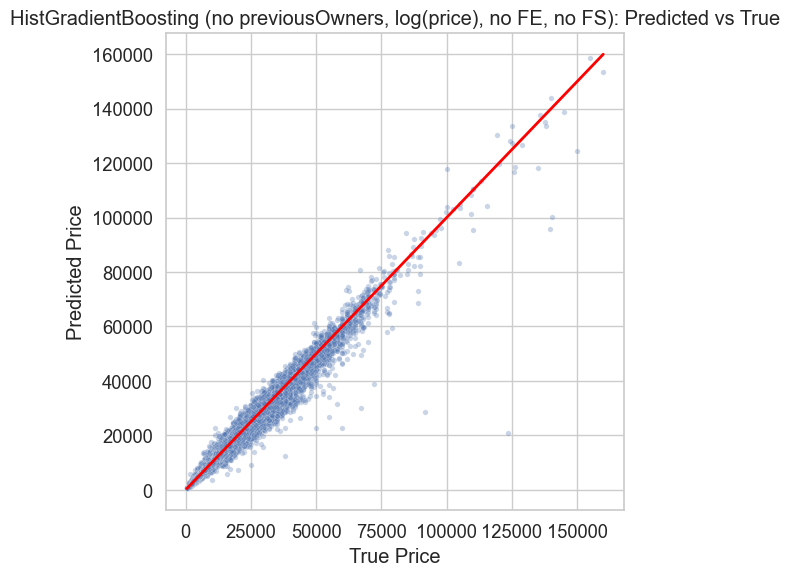

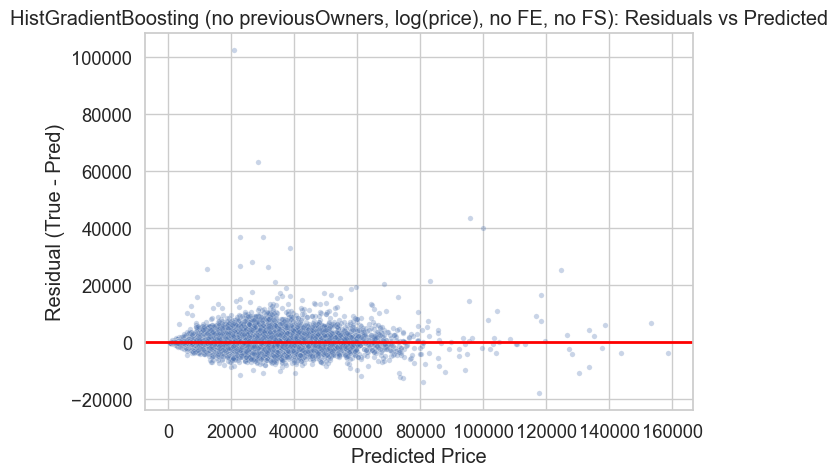

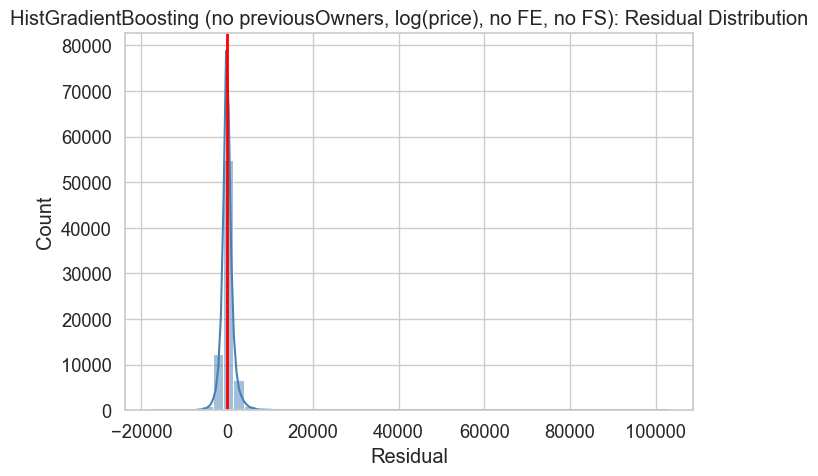

/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_90583/4128551160.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


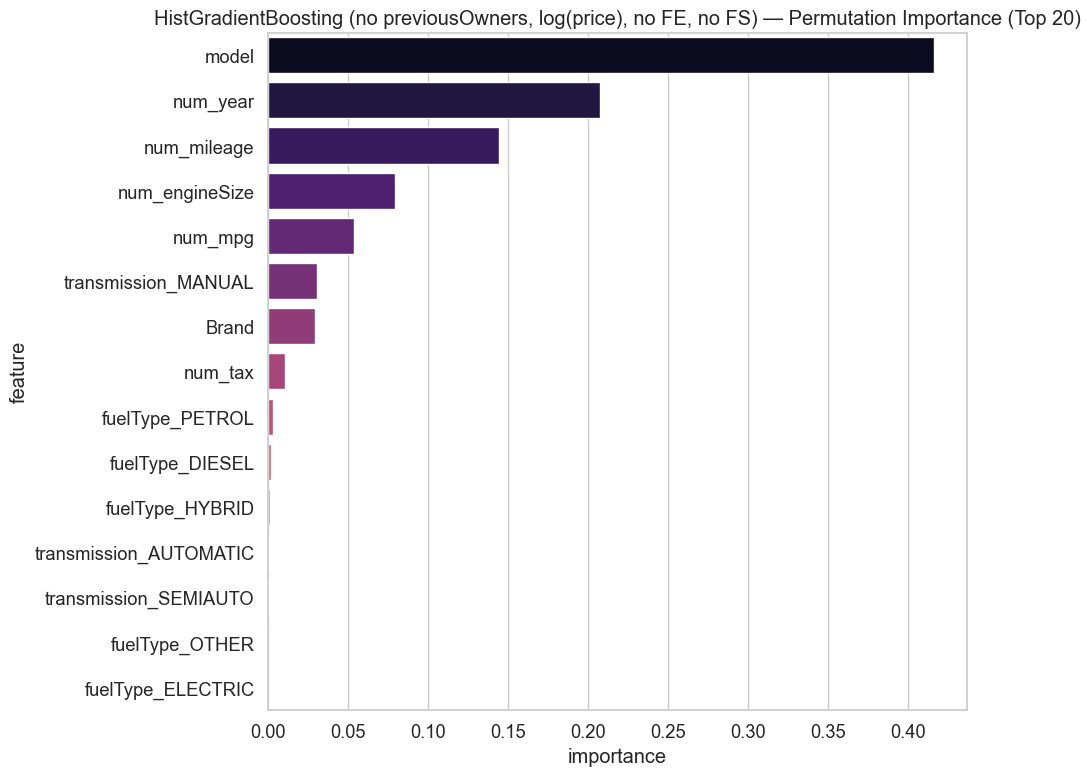

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/2000 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x104b45e40>
Traceback (most recent call last):
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104d99e40>
Traceback (most recent call last):
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 1


SHAP for HistGradientBoosting (no previousOwners, log(price), no FE, no FS) (sample size = 2000)


/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_90583/2697768544.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)


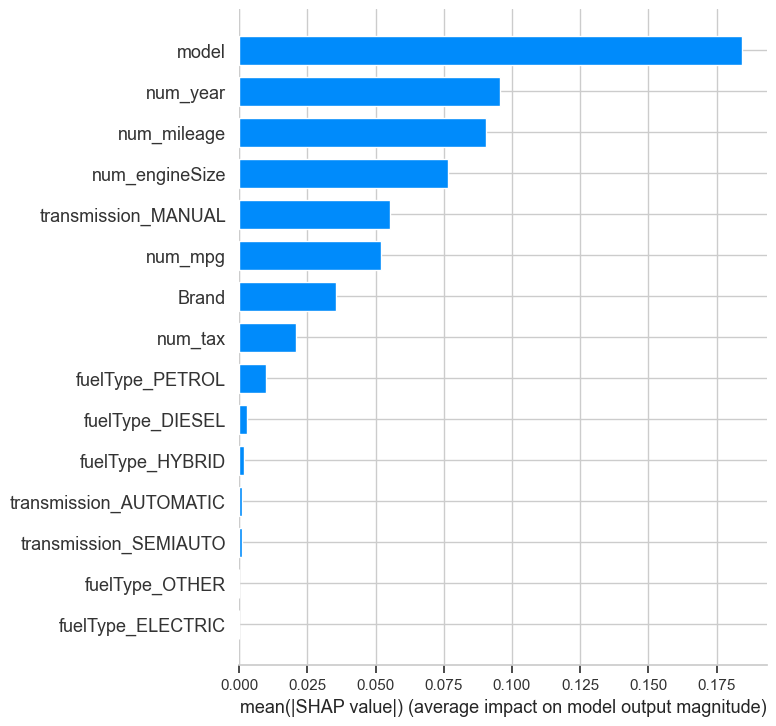

/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_90583/2697768544.py:74: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=True)


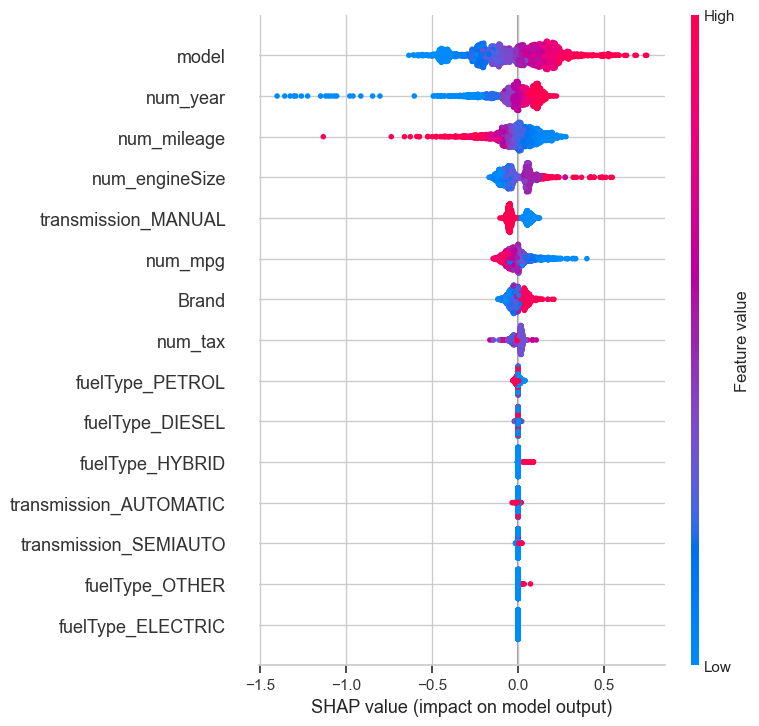

HistGradientBoostingRegressor does not expose feature_importances_. Using permutation importance / SHAP instead.
Split frequency is not available for HistGradientBoostingRegressor with this function (no estimators_).


In [ ]:
# Best config (setting: without previous owners, log target price)
best_params = {
    'min_samples_leaf': 20, 
    'max_leaf_nodes': 191, 
    'max_iter': 1000, 
    'max_depth': 20, 
    'loss': 'squared_error', 
    'learning_rate': 0.1, 
    'l2_regularization': 3.0
}

MODEL_NAME = "HistGradientBoosting (no previousOwners, log(price), no FE, no FS)"

# Building the full training matrix for this setting
numeric_features = ["year", "mileage", "engineSize", "tax", "mpg"]  # previousOwners excluded
categorical_features = ["Brand", "model", "transmission", "fuelType"]

X_full = X.copy()
y_full = y.copy()

# ensuring previousOwners never enters the pipeline
X_full = X_full.drop(columns=["previousOwners"], errors="ignore")

# log target (train in log)
y_full_log = np.log1p(y_full)

# Preprocessing (fit on full data, transform on full data)
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full,
    valid_brands=valid_brands,
    brand_col="Brand",
    model_col="model",
    year_col="year",
)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(
    train_df=X_full,
    valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand",
    model_col="model",
    year_col="year",
    fuel_col="fuelType",
    mpg_col="mpg",
)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(
    train_df=X_full,
    valid_transmissions=valid_transmissions,
    transm_col="transmission",
    brand_col="Brand",
    model_col="model",
    fuel_col="fuelType",
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full,
    valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType",
    brand_col="Brand",
    model_col="model",
    transm_col="transmission",
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

# Encoding (TE for Brand+model, OHE for the rest) 
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full_log)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

# Numeric scaling 
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{c}" for c in numeric_features],
)

# final matrix used for training and plots
X_full_sel = pd.concat([X_full_num_df, X_full_cat], axis=1)


# -> Model training (LOG TARGET)
hgb_best = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **best_params)
hgb_best.fit(X_full_sel, y_full_log)

# Running the visualizations for this model
plot_pred_vs_true_fs(hgb_best, MODEL_NAME)
plot_residuals_fs(hgb_best, MODEL_NAME)
plot_residual_distribution_fs(hgb_best, MODEL_NAME)
plot_permutation_importance_fs(hgb_best, MODEL_NAME, n_repeats=5, top=20)
apply_shap_fs(hgb_best, X_full_sel, model_name=MODEL_NAME, sample_size=2000)

# Feature importance (only if available)
if hasattr(hgb_best, "feature_importances_"):
    plot_feature_importance_fs(hgb_best, MODEL_NAME, top=20)
else:
    print("HistGradientBoostingRegressor does not expose feature_importances_. Using permutation importance / SHAP instead.")

# Split frequency is RF-specific (requires model.estimators_)
if hasattr(hgb_best, "estimators_"):
    split_freq_df = compute_split_frequency_fs(hgb_best)
    display(split_freq_df.head(30))
else:
    print("Split frequency is not available for HistGradientBoostingRegressor with this function (no estimators_).")



### 4.2. Results Obtained and Overall Performance Discussion

| Type of Experiment                              | FS ratio | RMSE (val)    | RMSE (train)  | MAE (val)    | MAE (train) | Amount of Features | Best config |
|---                                              |---:     |---:           |---:           |---:          |---:         |---:                |---|
| 3.1. Full Feature Set Experiment               | -       | 2125.233451   | 1633.375   | 1275.983400  | 1050.8  | 16                  | {'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': 20, 'learning_rate': 0.1, 'l2_regularization': 0} |
|  3.2.1. Feature Ablation Experiment: Excluding previousOwners and Applying a Log-Transformed Target (price)     | -       | 2111.819866   | 1605.3   | 1235.816682  | 969.5  | 15                  | {'min_samples_leaf': 20, 'max_leaf_nodes': 191, 'max_iter': 1000, 'max_depth': 20, 'loss': 'squared_error', 'learning_rate': 0.1, 'l2_regularization': 3.0} |
| 3.3.1. Original and Engineered Features (No Feature Selection) with Log-Transformed Target (price)         | -       | 2166.386  | 1697.414446   | 1262.987  | 1028.13955  | 25                  | {'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 800, 'max_depth': 15, 'learning_rate': np.float64(0.08736842105263158), 'l2_regularization': np.float64(1.236842105263158), 'max_bins': 255, 'random_state': 42} |
| 3.3.2.1 Original and Engineered Features (with Feature Selection of 65%) with Log-Transformed Target (price)         | 0.65       | 2138.946  | 1656.389980  | 1254.963  | 1000.731919  | 17                  | {'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 1000, 'max_depth': 25, 'learning_rate': np.float64(0.12052631578947368), 'l2_regularization': np.float64(2.394736842105263), 'max_bins': 255, 'random_state': 42} |
| 3.3.3.1. Combining age and Excluding previousOwners Features and Applying Log-Transformed Target (price)     | -       | 2111.9944  | 1602.125  | 1233.552  | 969.2 | 15                  | {'min_samples_leaf': 16, 'max_leaf_nodes': 191, 'max_iter': 1200, 'max_depth': 20, 'loss': 'squared_error', 'learning_rate': 0.07, 'l2_regularization': 3.0} |
| 3.3.3.2. Combining age and Excluding previousOwners Features (with Feature Selection of 80%) and Applying a Log-Transformed Target (price)       | 0.8       | 2113.1869  | 1661  | 1239.187341  | 1009.3 | 12                  | {'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': 15, 'loss': 'squared_error', 'learning_rate': 0.1, 'l2_regularization': 3.0} |

*Table 1 - Best configuration and main metrics for each experiment.*


<div style="text-align: justify; max-width: 1300px; margin: 1 auto;">

- Our best obtained RMSE was approximately 2112 for the settings "Feature Ablation Experiment: Excluding previousOwners and Applying a Log-Transformed Target (price)" (3.2) and "Combining age and Excluding previousOwners Features and Applying Log-Transformed Target (price)" (3.3.3.), with approximate validation MAE scores of 1235.8 and 1233.6. Since they only differ on the age, we are led to believe that changing year to age didn't produce a big change here, however, the parameter configurations were not the same, so we can't conclude this for sure.

- Looking at the table with the best configuration for each experiment, we can see that the performances are consistent across them. However, we notice slightly worse results when more features are used, particularly when the full set of features is included, especially with the additional engineered ones. As expected, this could be due to the redundancy introduced by the larger number of features.

- Finally, we also considered the risk of __overfitting__, which is common in decision-tree-based models (and ensembles of them). We observed a slight difference between __training__ and __validation__ errors (both RMSE and MAE). However, since we used __8-fold cross-validation__, and the validation metrics were relatively stable across folds while remaining competitive overall, we considered this behavior acceptable.

- From the previous plots and table we can get some important takeaways about the model's behaviour:

    - In the "Predicted vs True" plot, we can observe that most points are very close to the diagonal for the common price range, which suggests the model fits typical cars well. For very high prices, there is some dispersion. This behavior was already expected, since cars in this price range are rarer in the dataset and harder to learn.

    - Residuals are mostly centered around 0, but they become more spread as predicted price increases. The majority of residuals are positive, especially the more extreme ones, meaning the model sometimes (strongly) underestimates the prices, potentially for rarer cars in the dataset, or with rarer combinations of attributes, and for more expensive cars.

    - The distribution is centered near zero, indicating that there are, in general, more small errors. But still presents some considerable tails. So, most predictions are close to the real value, but for some sets of cars there are still some larger errors.

    - Through the analysis of the permutation importance plot, it's clear that the model feature is the most influential, followed by year and mileage. Then, the engineSize and mpg features follow. Transmission is relevant only to the extent of knowing if it's manual or not and brand has a very similar effect, but much less than the top group. The remaining features (especially the other transmissions and fuel types) have a very small contribution. 

    - SHAP importance bar plot confirms the same top ranking as the permutation importance plot (model, year, mileage and then engineSize). This consistency is a good indicator of the stability of these visualisation techniques (meaning the results are most likely real and not just an artifact of the chosen technique). 

    - Regarding the direction of effects, a higher value of year (i.e. a more recent car) tends to increase the prediction while older cars tend to decrease it. Higher mileage tends to reduce the predicted price and a larger value of engine size is associated with a higher price. Fuel type indicators have a near zero impact for most samples, which matches what was observed in the importance plots. 

- In conclusion, this model behaves in a very reasonable way, predicting well for the majority of vehicles, but failing more for cars with extreme prices. The log target setting likely helped stability on typical values but can still lead to the flattening of the extreme prices. The combination of excluding previousOwners and applying the logarithmic transformation to price seems to lead, among the tested settings, to improved RMSE and MAE scores.


</div>